# 🧠 Battleship AI — Neural Network (DQN) Edition

## การเปรียบเทียบ Model เดิม vs Neural Network

| วิธี | หลักการ | ข้อจำกัด |
|------|---------|----------|
| Hunt+Target | Rule-based | ไม่เรียนรู้ จาก pattern |
| Bayesian Map | สถิติ + คำนวณ prob ทุก turn | ใช้ compute สูง |
| Q-Learning | Q-Table (สถานะ → action) | State space ใหญ่เกินไป (2^100) |
| **DQN (Neural Network)** | **Neural Net ประมาณ Q-values** | **Generalize ได้ ไม่ต้องเก็บทุก state** |

---

## 🏗️ สถาปัตยกรรมของ DQN (Deep Q-Network)

```
INPUT LAYER (300 neurons)
  ├─ Board State    : 100 values  → 0=unknown, 1=hit, -1=miss
  ├─ Prob Map       : 100 values  → Historical probability ของแต่ละช่อง
  └─ Action Mask    : 100 values  → 1=ยังยิงได้, 0=ยิงไปแล้ว
          │
       [Dense 256, ReLU]
          │
       [BatchNorm]
          │
       [Dropout 0.2]
          │
       [Dense 256, ReLU]
          │
       [BatchNorm]
          │
       [Dense 128, ReLU]
          │
OUTPUT LAYER (100 neurons) → Q-value ของแต่ละช่อง (0-99)
```

## 🔁 กระบวนการเรียนรู้ (DQN Training Loop)

```
1. ε-Greedy Action Selection
   ┌─ random() < ε  → สุ่ม action (Exploration)
   └─ random() ≥ ε  → argmax(Q_network(state))  (Exploitation)

2. Receive Reward
   ├─ Hit   (โดนเรือ)  : +10
   ├─ Sunk  (จมเรือ)   : +50
   └─ Miss  (พลาด)     : -1

3. Store in Replay Buffer  (s, a, r, s', done)

4. Sample Mini-batch และ Compute Target
   target = r + γ × max(Q_target(s'))   ← Bellman Equation

5. Update Q_network ด้วย Gradient Descent
   Loss = MSE(Q_network(s,a), target)

6. ทุก C steps: copy weights → Q_target   ← Target Network Trick
```


---
## ⚙️ Install Dependencies

In [3]:
!pip install -q tensorflow streamlit
!npm install localtunnel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 83.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 131.7 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇
added 22 packages in 2s
⠇
⠇3 packages are looking for funding
⠇  run `npm fund` for details
⠇

---
## 📂 Import Dataset & Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import collections
import time
from IPython.display import clear_output

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers

# ─── Reproducibility ───────────────────────────────────────
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# ─── Load Data ─────────────────────────────────────────────
df_squares = pd.read_csv('battleship_game_squares.csv')
df_games   = pd.read_csv('battleship_games.csv')
df_moves   = pd.read_csv('battleship_game_moves.csv')

print('✅ Data loaded')
print(f'   df_games   : {df_games.shape}')
print(f'   df_squares : {df_squares.shape}')
print(f'   df_moves   : {df_moves.shape}')
print(f'   TensorFlow : {tf.__version__}')

✅ Data loaded
   df_games   : (59710, 6)
   df_squares : (2400, 7)
   df_moves   : (1008, 6)
   TensorFlow : 2.19.0


---
## 📊 EDA: วิเคราะห์ข้อมูลก่อน Train

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/tmp/ipykernel_12483/3316062198.py:39: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaV

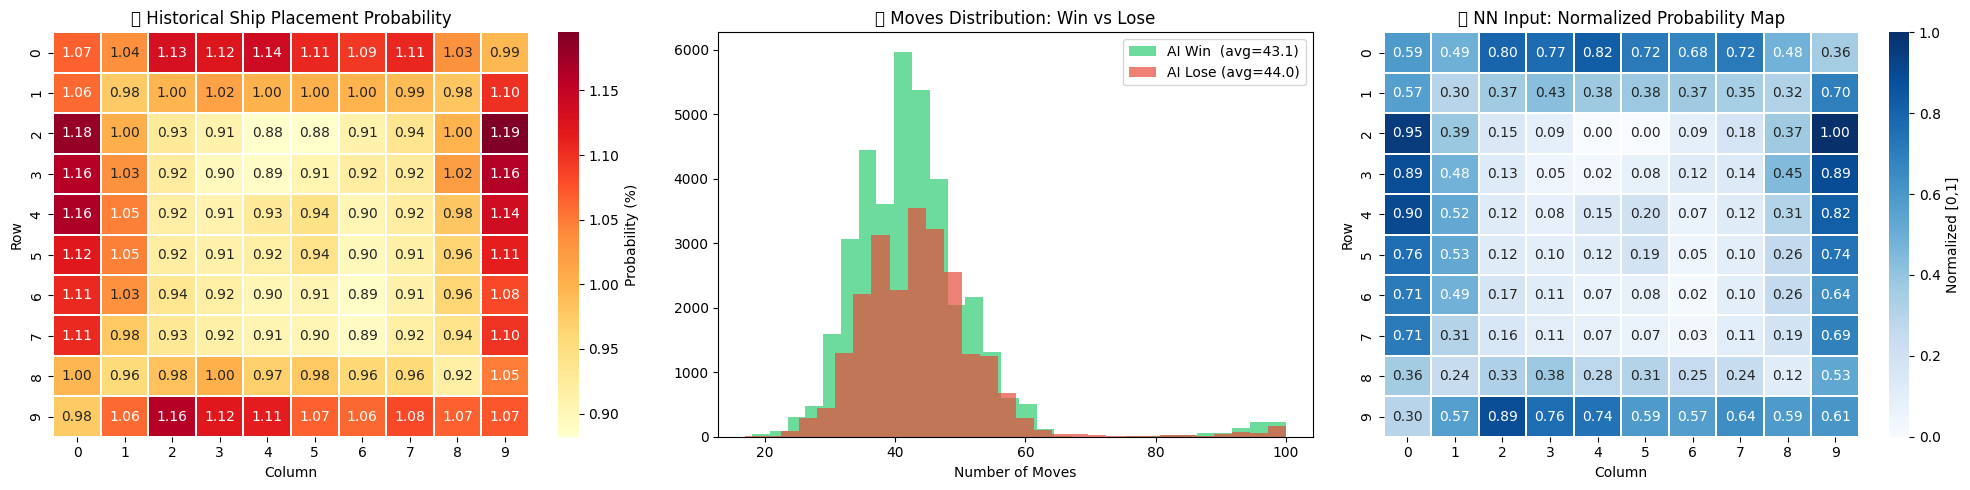

AI Win Rate (ข้อมูลจริง): 61.1%
Avg Moves to finish     : 43.4


In [9]:
# ─── Build Base Probability Map จาก Historical Data ────────
player_data  = df_squares[df_squares['ai_ships'] == 0].copy()
stats        = player_data.groupby('square')['games'].sum().reset_index()
stats['probability'] = stats['games'] / stats['games'].sum() * 100

BASE_PROB = np.zeros(100)
for _, row in stats.iterrows():
    idx = int(row['square']) - 1
    if 0 <= idx < 100:
        BASE_PROB[idx] = row['probability']

# Normalize to [0,1]
BASE_PROB_NORM = (BASE_PROB - BASE_PROB.min()) / (BASE_PROB.max() - BASE_PROB.min())

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Historical Heatmap
sns.heatmap(BASE_PROB.reshape(10, 10), ax=axes[0],
            cmap='YlOrRd', annot=True, fmt='.2f', linewidths=.3,
            cbar_kws={'label': 'Probability (%)'})
axes[0].set_title('📍 Historical Ship Placement Probability', fontsize=12)
axes[0].set_xlabel('Column'); axes[0].set_ylabel('Row')

# 2. Win vs Loss Distribution
win_g  = df_games[df_games['ai_win'] == 1]['moves']
lose_g = df_games[df_games['ai_win'] == 0]['moves']
axes[1].hist(win_g,  bins=30, alpha=0.7, label=f'AI Win  (avg={win_g.mean():.1f})',  color='#2ecc71')
axes[1].hist(lose_g, bins=30, alpha=0.7, label=f'AI Lose (avg={lose_g.mean():.1f})', color='#e74c3c')
axes[1].set_title('📈 Moves Distribution: Win vs Lose', fontsize=12)
axes[1].set_xlabel('Number of Moves'); axes[1].legend()

# 3. Heatmap ของ Normalized Prob (ที่จะใส่ใน NN)
sns.heatmap(BASE_PROB_NORM.reshape(10, 10), ax=axes[2],
            cmap='Blues', annot=True, fmt='.2f', linewidths=.3,
            cbar_kws={'label': 'Normalized [0,1]'})
axes[2].set_title('🧠 NN Input: Normalized Probability Map', fontsize=12)
axes[2].set_xlabel('Column'); axes[2].set_ylabel('Row')

plt.tight_layout()
plt.show()

print(f"AI Win Rate (ข้อมูลจริง): {df_games['ai_win'].mean()*100:.1f}%")
print(f"Avg Moves to finish     : {df_games['moves'].mean():.1f}")

---
## 🎮 Game Environment

สร้าง Environment ของ Battleship สำหรับ Training

In [10]:
# ─── Constants ─────────────────────────────────────────────
SHIP_LENGTHS   = [5, 4, 3, 3, 2]
TOTAL_SHIP_CELLS = sum(SHIP_LENGTHS)   # = 17
BOARD_SIZE     = 100

# ─── Reward Structure (Reward Shaping) ─────────────────────
R_MISS  = -1.0    # พลาด
R_HIT   = 10.0   # โดนเรือ
R_SUNK  = 50.0   # จมเรือได้ (bonus)
R_WIN   = 100.0  # ชนะ (จมเรือทุกลำ)


def random_board():
    """
    สร้างกระดาน Battleship แบบสุ่ม
    Returns:
        board      : np.array shape (100,) — ship_id+1 หรือ 0
        ship_cells : list of lists — ช่องที่แต่ละเรืออยู่
    """
    board      = np.zeros(100, dtype=int)
    ship_cells = []

    for ship_idx, length in enumerate(SHIP_LENGTHS):
        placed = False
        while not placed:
            horizontal = random.random() < 0.5
            if horizontal:
                r = random.randint(0, 9)
                c = random.randint(0, 9 - length + 1)
                cells = [r * 10 + c + j for j in range(length)]
            else:
                r = random.randint(0, 9 - length + 1)
                c = random.randint(0, 9)
                cells = [(r + j) * 10 + c for j in range(length)]

            if all(board[cell] == 0 for cell in cells):
                for cell in cells:
                    board[cell] = ship_idx + 1
                ship_cells.append(cells)
                placed = True

    return board, ship_cells


class BattleshipEnv:
    """
    Battleship Environment สำหรับ RL Training

    State Encoding (300 dimensions):
    ┌────────────────────────────────────────────────────────┐
    │  [0:100]   board_state  — 0=unknown, 1=hit, -1=miss    │
    │  [100:200] prob_map     — Normalized historical prob    │
    │  [200:300] action_mask  — 1=available, 0=shot already  │
    └────────────────────────────────────────────────────────┘
    """

    STATE_DIM  = 300    # 3 × 100
    ACTION_DIM = 100    # ช่องบนกระดาน

    def __init__(self, base_prob_norm):
        self.base_prob_norm = base_prob_norm
        self.reset()

    def reset(self):
        self.board, self.ship_cells = random_board()
        self.board_state = np.zeros(100)   # 0=unknown, 1=hit, -1=miss
        self.guessed     = set()
        self.hits_count  = 0
        self.sunk_ships  = [False] * len(SHIP_LENGTHS)
        return self._get_state()

    def _get_state(self):
        action_mask = np.ones(100)
        for sq in self.guessed:
            action_mask[sq] = 0.0
        return np.concatenate([
            self.board_state,        # [0:100]
            self.base_prob_norm,     # [100:200]
            action_mask              # [200:300]
        ]).astype(np.float32)

    def step(self, action):
        """
        ยิงที่ช่อง action
        Returns: (next_state, reward, done)
        """
        assert action not in self.guessed, f"Action {action} already played!"
        self.guessed.add(action)

        is_hit    = self.board[action] > 0
        ship_idx  = self.board[action] - 1
        reward    = 0.0
        done      = False

        if is_hit:
            self.board_state[action] = 1.0
            self.hits_count += 1
            reward += R_HIT

            # Check สิ่งเรือจมหรือยัง
            if not self.sunk_ships[ship_idx]:
                if all(cell in self.guessed for cell in self.ship_cells[ship_idx]):
                    self.sunk_ships[ship_idx] = True
                    reward += R_SUNK

            # Check ชนะหรือยัง
            if self.hits_count == TOTAL_SHIP_CELLS:
                reward += R_WIN
                done = True
        else:
            self.board_state[action] = -1.0
            reward += R_MISS

        return self._get_state(), reward, done

    def get_valid_actions(self):
        return [i for i in range(100) if i not in self.guessed]


print('✅ BattleshipEnv พร้อมใช้งาน')
print(f'   State dimension  : {BattleshipEnv.STATE_DIM}')
print(f'   Action dimension : {BattleshipEnv.ACTION_DIM}')
print(f'   Total ship cells : {TOTAL_SHIP_CELLS}')

✅ BattleshipEnv พร้อมใช้งาน
   State dimension  : 300
   Action dimension : 100
   Total ship cells : 17


---
## 🧠 Neural Network Architecture

### ทำไมต้องใช้ DQN แทน Q-Table?

| | Q-Table | DQN |
|---|---|---|
| State representation | ต้องเก็บ 2^100 ≈ 10^30 states | Neural Net **ประมาณ** Q-values |
| Memory | เป็นไปไม่ได้ | เก็บแค่ weights (~500K params) |
| Generalization | ไม่ได้ | **ได้** — state ที่ไม่เคยเห็นก็ประมาณได้ |
| Training | ช้า | เร็วกว่าด้วย GPU |

### Architecture ที่ใช้: **Dueling DQN**
```
Input → [Shared Layers] → ┬─ [Advantage Stream A(s,a)] ─→ ┐
                          └─ [Value Stream    V(s)    ] ─→ ┘→ Q(s,a) = V(s) + A(s,a) - mean(A)
```
- **V(s)**: มูลค่าของ state ว่าสถานการณ์นี้ดีแค่ไหน
- **A(s,a)**: ข้อได้เปรียบของ action นี้เมื่อเทียบกับค่าเฉลี่ย
- รวมกัน: เรียนรู้ได้เสถียรกว่า DQN ปกติ

In [12]:
# ─── Custom Layer แทน Lambda ─────────────────────────────────
# Lambda layer serialize เป็น Python bytecode → Keras 3 ปฏิเสธโหลด
# แก้ด้วย custom layer ที่ register ชื่อไว้ → serialize/deserialize ได้ปลอดภัย

@keras.utils.register_keras_serializable(package="battleship")
class AdvantageMean(keras.Layer):
    """
    คำนวณ mean ของ advantage values ตาม action dimension
    แทน Lambda เพื่อให้ .keras serialize/deserialize ได้ปลอดภัย

    Input  : (batch, action_dim)
    Output : (batch, 1)  — mean ตาม axis=1
    """
    def call(self, adv):
        return tf.reduce_mean(adv, axis=1, keepdims=True)

    def get_config(self):
        return super().get_config()   # ไม่มี extra config → base เพียงพอ


def build_dueling_dqn(state_dim=300, action_dim=100,
                       hidden_units=[256, 256, 128],
                       learning_rate=1e-3):
    """
    Dueling DQN — ใช้ AdvantageMean layer แทน Lambda
    serialize/deserialize ได้กับ .keras format ของ Keras 3
    """
    inputs = keras.Input(shape=(state_dim,), name='state_input')

    # ─── Shared Feature Extraction ──────────────────────────
    x = inputs
    for i, units in enumerate(hidden_units):
        x = layers.Dense(units, name=f'shared_dense_{i+1}')(x)
        if i < len(hidden_units) - 1:
            x = layers.BatchNormalization(name=f'bn_{i+1}')(x)
        x = layers.Activation('relu', name=f'relu_{i+1}')(x)
        if i < len(hidden_units) - 1:
            x = layers.Dropout(0.2, name=f'dropout_{i+1}')(x)

    # ─── Advantage Stream A(s, a) ────────────────────────────
    adv = layers.Dense(64, activation='relu', name='adv_hidden')(x)
    adv = layers.Dense(action_dim, name='advantage')(adv)

    # ─── Value Stream V(s) ──────────────────────────────────
    val = layers.Dense(64, activation='relu', name='val_hidden')(x)
    val = layers.Dense(1, name='value')(val)

    # ─── Combine: Q = V + (A - mean(A)) ─────────────────────
    # ⚡ AdvantageMean layer แทน Lambda → serialize ได้
    adv_mean    = AdvantageMean(name='adv_mean')(adv)
    adv_centered = layers.Subtract(name='adv_centered')([adv, adv_mean])
    q_values    = layers.Add(name='q_values')([val, adv_centered])

    model = keras.Model(inputs=inputs, outputs=q_values, name='DuelingDQN')
    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate, clipnorm=1.0),
        loss='huber'
    )
    return model


# ─── Build & Show Summary ────────────────────────────────────
model_demo = build_dueling_dqn()
model_demo.summary()
print(f'\nTotal trainable params: {model_demo.count_params():,}')


Model: "DuelingDQN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ state_input         │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dense_1      │ (None, 256)       │     77,056 │ state_input[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_1                │ (None, 256)       │      1,024 │ shared_dense_1[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu_1 (Activation) │ (None, 256)       │          0 │ bn_1[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ relu_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dense_2      │ (None, 256)       │     65,792 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2                │ (None, 256)       │      1,024 │ shared_dense_2[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu_2 (Activation) │ (None, 256)       │          0 │ bn_2[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ relu_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dense_3      │ (None, 128)       │     32,896 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu_3 (Activation) │ (None, 128)       │          0 │ shared_dense_3[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ adv_hidden (Dense)  │ (None, 64)        │      8,256 │ relu_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ advantage (Dense)   │ (None, 100)       │      6,500 │ adv_hidden[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ val_hidden (Dense)  │ (None, 64)        │      8,256 │ relu_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ adv_mean            │ (None, 1)         │          0 │ advantage[0][0]   │
│ (AdvantageMean)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ value (Dense)       │ (None, 1)         │         65 │ val_hidden[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ adv_centered        │ (None, 100)       │          0 │ advantage[0][0],  │
│ (Subtract)          │                   │            │ adv_mean[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_values (Add)      │ (None, 100)       │          0 │ value[0][0],      │
│                     │                   │            │ adv_centered[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 200,869 (784.64 KB)

 Trainable params: 199,845 (780.64 KB)

 Non-trainable params: 1,024 (4.00 KB)


Total trainable params: 200,869


---
## 🗄️ Experience Replay Buffer

**ทำไมต้องมี Replay Buffer?**

ถ้า train แบบ online (experience ต่อ experience) จะเกิดปัญหา:
- **Correlation**: experiences ต่อเนื่องกันมี correlation สูง → network เรียนรู้ผิด
- **Catastrophic Forgetting**: เรียนรู้ experience ใหม่แล้วลืม experience เก่า

**วิธีแก้**: เก็บ experience ใน buffer แล้ว **sample แบบสุ่ม** มา train

In [13]:
class ReplayBuffer:
    """
    Experience Replay Buffer

    เก็บ transition (state, action, reward, next_state, done)
    และ sample แบบสุ่มมา train เพื่อ break correlation

    ใช้ deque ที่มี maxlen เพื่อให้ experience เก่าถูกลบอัตโนมัติ
    เมื่อ buffer เต็ม (FIFO policy)
    """

    def __init__(self, max_size=50_000):
        self.buffer   = collections.deque(maxlen=max_size)
        self.max_size = max_size

    def push(self, state, action, reward, next_state, done):
        """เพิ่ม 1 transition เข้า buffer"""
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        """
        สุ่ม mini-batch ขนาด batch_size จาก buffer
        Returns numpy arrays ที่พร้อม feed เข้า network
        """
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            np.array(states,      dtype=np.float32),
            np.array(actions,     dtype=np.int32),
            np.array(rewards,     dtype=np.float32),
            np.array(next_states, dtype=np.float32),
            np.array(dones,       dtype=np.float32),
        )

    def __len__(self):
        return len(self.buffer)


print('✅ ReplayBuffer พร้อมใช้งาน')

✅ ReplayBuffer พร้อมใช้งาน


---
## 🤖 DQN Agent

### อัลกอริธึมหลัก: **Double DQN + Dueling + Prioritized Experience Replay**

**Double DQN** แก้ปัญหา Overestimation:
```
Standard DQN : target = r + γ × max_a Q_target(s', a)
Double DQN   : target = r + γ × Q_target(s', argmax_a Q_online(s', a))
```
- ใช้ Q_online เลือก action
- ใช้ Q_target ประเมินค่า
→ ลด bias จากการ overestimate

In [14]:
class DQNAgent:
    """
    Deep Q-Network Agent สำหรับ Battleship (Fast Version)

    ⚡ Speed Optimizations vs เวอร์ชันเดิม:
    ┌────────────────────────────────────────────────────────────┐
    │  เดิม: model.fit(epochs=1)     → overhead ทุก step       │
    │  ใหม่: @tf.function + GradientTape → JIT-compiled 10-30x  │
    │  เดิม: learn() ทุก step        → ช้า                      │
    │  ใหม่: learn ทุก TRAIN_EVERY steps → ลด overhead 4x       │
    │  เดิม: tf.convert_to_tensor ทุกครั้ง → ใช้ numpy/cache    │
    │  ใหม่: pre-allocate + vectorised numpy ops                 │
    └────────────────────────────────────────────────────────────┘
    """

    BATCH_SIZE       = 128
    GAMMA            = 0.95
    EPSILON_START    = 1.0
    EPSILON_MIN      = 0.05
    EPSILON_DECAY    = 0.9990
    LR               = 5e-4
    TARGET_UPDATE_FREQ = 50    # episodes
    MIN_BUFFER_SIZE  = 2_000
    BUFFER_SIZE      = 50_000
    TRAIN_EVERY      = 4       # ⚡ learn ทุก 4 steps แทนทุก step

    def __init__(self, state_dim, action_dim, base_prob_norm):
        self.state_dim       = state_dim
        self.action_dim      = action_dim
        self.base_prob_norm  = base_prob_norm
        self.epsilon         = self.EPSILON_START
        self.episode_count   = 0
        self.step_count      = 0        # global step counter

        self.q_online  = build_dueling_dqn(state_dim, action_dim, learning_rate=self.LR)
        self.q_target  = build_dueling_dqn(state_dim, action_dim, learning_rate=self.LR)
        self._update_target_network()

        self.replay_buffer = ReplayBuffer(max_size=self.BUFFER_SIZE)

        self.episode_rewards  = []
        self.episode_moves    = []
        self.loss_history     = []

        # ⚡ Optimizer แยกออกมา (ใช้ร่วมกับ tf.function)
        self.optimizer = tf.keras.optimizers.Adam(
            learning_rate=self.LR, clipnorm=1.0)
        self.huber     = tf.keras.losses.Huber()

        # ⚡ JIT-compile training step ครั้งแรก (warm-up ครั้งเดียว)
        self._compiled_train_step = tf.function(
            self._train_step_inner,
            reduce_retracing=True
        )

    # ══════════════════════════════════════════════════════
    # ⚡ Inner Training Step — compiled ด้วย @tf.function
    # ══════════════════════════════════════════════════════
    def _train_step_inner(self, states, actions, rewards,
                          next_states, dones):
        """
        JIT-compiled training step (ทำงานเป็น TF graph ไม่ใช่ Python loop)

        Double DQN Bellman Update:
          a*     = argmax_a  Q_online(s', a)        ← online เลือก action
          target = r + γ × Q_target(s', a*) × (1-done)  ← target ประเมินค่า
          loss   = Huber(Q_online(s,a), target)
        """
        # ─── Double DQN: online เลือก a*, target ประเมินค่า ────────
        next_q_online  = self.q_online(next_states, training=False)
        best_actions   = tf.argmax(next_q_online, axis=1, output_type=tf.int32)

        next_q_target  = self.q_target(next_states, training=False)

        # gather Q_target(s', a*) สำหรับแต่ละ sample ใน batch
        batch_idx      = tf.range(tf.shape(best_actions)[0], dtype=tf.int32)
        gather_idx     = tf.stack([batch_idx, best_actions], axis=1)
        best_q_target  = tf.gather_nd(next_q_target, gather_idx)

        # Bellman target
        td_target      = rewards + self.GAMMA * best_q_target * (1.0 - dones)

        # ─── Gradient Descent ───────────────────────────────────────
        with tf.GradientTape() as tape:
            q_pred  = self.q_online(states, training=True)        # (batch, 100)

            # index Q-value ของ action ที่เลือก
            act_idx = tf.stack([batch_idx, actions], axis=1)
            q_taken = tf.gather_nd(q_pred, act_idx)              # (batch,)

            loss    = self.huber(td_target, q_taken)

        grads = tape.gradient(loss, self.q_online.trainable_variables)
        self.optimizer.apply_gradients(
            zip(grads, self.q_online.trainable_variables))
        return loss

    # ══════════════════════════════════════════════════════
    # Action Selection
    # ══════════════════════════════════════════════════════
    def select_action(self, state, valid_actions, training=True):
        if not valid_actions:
            return 0

        if training and random.random() < self.epsilon:
            return random.choice(valid_actions)

        # ⚡ ใช้ numpy โดยตรง ไม่ผ่าน tf.convert_to_tensor ทุกครั้ง
        state_np  = state[np.newaxis, :].astype(np.float32)
        q_values  = self.q_online(state_np, training=False).numpy()[0]

        mask = np.full(self.action_dim, -np.inf)
        mask[valid_actions] = q_values[valid_actions]
        return int(np.argmax(mask))

    # ══════════════════════════════════════════════════════
    # ⚡ Fast Learn — เรียกทุก TRAIN_EVERY steps
    # ══════════════════════════════════════════════════════
    def learn(self):
        self.step_count += 1

        # ⚡ skip ถ้ายังไม่ถึงรอบ train หรือ buffer ยังไม่พอ
        if (self.step_count % self.TRAIN_EVERY != 0 or
                len(self.replay_buffer) < self.MIN_BUFFER_SIZE):
            return None

        states, actions, rewards, next_states, dones = \
            self.replay_buffer.sample(self.BATCH_SIZE)

        # แปลงเป็น tensor ครั้งเดียวก่อนส่งเข้า tf.function
        s_t  = tf.constant(states,      dtype=tf.float32)
        a_t  = tf.constant(actions,     dtype=tf.int32)
        r_t  = tf.constant(rewards,     dtype=tf.float32)
        ns_t = tf.constant(next_states, dtype=tf.float32)
        d_t  = tf.constant(dones,       dtype=tf.float32)

        loss = self._compiled_train_step(s_t, a_t, r_t, ns_t, d_t)
        loss_val = float(loss.numpy())
        self.loss_history.append(loss_val)
        return loss_val

    def _update_target_network(self):
        self.q_target.set_weights(self.q_online.get_weights())

    def _decay_epsilon(self):
        if self.epsilon > self.EPSILON_MIN:
            self.epsilon *= self.EPSILON_DECAY

    def pretrain_from_data(self, base_prob_norm, epochs=5):
        """
        ⚡ Pre-training ด้วย train_on_batch แทน fit() เพื่อลด overhead
        """
        print("🔄 Pre-training from historical data...")
        env = BattleshipEnv(base_prob_norm)
        states_list, targets_list = [], []

        for _ in range(500):
            state  = env.reset()
            target = base_prob_norm * 5.0
            states_list.append(state)
            targets_list.append(target)

        X = np.array(states_list, dtype=np.float32)
        y = np.array(targets_list, dtype=np.float32)

        # ⚡ train_on_batch แทน fit() — ไม่มี epoch overhead
        batch_sz = 64
        for ep in range(epochs):
            idx = np.random.permutation(len(X))
            for start in range(0, len(X), batch_sz):
                b = idx[start:start + batch_sz]
                self.q_online.train_on_batch(X[b], y[b])

        self._update_target_network()
        print(f"  ✅ Pre-training เสร็จสิ้น ({len(X)} samples, {epochs} epochs)")


print("✅ DQNAgent (Fast) พร้อมใช้งาน")
print(f"   TRAIN_EVERY = {DQNAgent.TRAIN_EVERY} steps  (เร็วขึ้น ~4x)")
print(f"   @tf.function JIT compile  (เร็วขึ้น ~10–30x vs model.fit)")


✅ DQNAgent (Fast) พร้อมใช้งาน
   TRAIN_EVERY = 4 steps  (เร็วขึ้น ~4x)
   @tf.function JIT compile  (เร็วขึ้น ~10–30x vs model.fit)


---
## 🏋️ Training Loop

### ขั้นตอนการ Train DQN:

```
For episode = 1 to N:
  state = env.reset()             ← สุ่มกระดานใหม่
  done  = False
  total_reward = 0

  While not done:
    action = agent.select_action(state, valid_actions)  ← ε-Greedy
    next_state, reward, done = env.step(action)          ← ยิง
    buffer.push(state, action, reward, next_state, done) ← เก็บ
    loss = agent.learn()                                 ← อัปเดต NN
    state = next_state
    total_reward += reward

  agent.decay_epsilon()                                  ← ลด ε
  if episode % C == 0:
    agent.update_target_network()                        ← sync weights
```

In [17]:
def train_dqn(n_episodes=3_000, log_interval=200):
    """
    ⚡ Fast Training Loop

    การปรับปรุงความเร็ว:
    1. learn() เรียกทุก TRAIN_EVERY steps ไม่ใช่ทุก step
    2. _compiled_train_step ใช้ @tf.function (JIT-compiled TF graph)
    3. GradientTape แทน model.fit() — ไม่มี epoch/callback overhead
    4. Tensor ถูก cast ครั้งเดียวก่อนส่งเข้า compiled function
    """
    env   = BattleshipEnv(BASE_PROB_NORM)
    agent = DQNAgent(
        state_dim      = BattleshipEnv.STATE_DIM,
        action_dim     = BattleshipEnv.ACTION_DIM,
        base_prob_norm = BASE_PROB_NORM
    )

    agent.pretrain_from_data(BASE_PROB_NORM, epochs=5)

    # ⚡ Warm-up tf.function (compile graph ครั้งแรก ไม่นับเวลา)
    print("⚙️  Warming up @tf.function (one-time JIT compile)...")
    dummy = np.zeros((DQNAgent.BATCH_SIZE, BattleshipEnv.STATE_DIM), dtype=np.float32)
    dummy_a = np.zeros(DQNAgent.BATCH_SIZE, dtype=np.int32)
    dummy_r = np.zeros(DQNAgent.BATCH_SIZE, dtype=np.float32)
    dummy_d = np.zeros(DQNAgent.BATCH_SIZE, dtype=np.float32)
    agent._compiled_train_step(
        tf.constant(dummy), tf.constant(dummy_a),
        tf.constant(dummy_r), tf.constant(dummy),
        tf.constant(dummy_d)
    )
    print("   ✅ JIT warm-up เสร็จสิ้น\n")

    print(f"🚀 Starting DQN Training for {n_episodes:,} episodes...")
    print("─" * 65)

    start_time = time.time()

    for ep in range(1, n_episodes + 1):
        state  = env.reset()
        done   = False
        total_reward = 0.0
        moves  = 0

        while not done:
            valid  = env.get_valid_actions()
            action = agent.select_action(state, valid, training=True)

            next_state, reward, done = env.step(action)
            agent.replay_buffer.push(state, action, reward, next_state, float(done))

            # ⚡ learn() ตรวจ TRAIN_EVERY ภายใน — ไม่ต้องทำ if-check ที่นี่
            agent.learn()

            state         = next_state
            total_reward += reward
            moves        += 1

        agent.episode_rewards.append(total_reward)
        agent.episode_moves.append(moves)
        agent.episode_count += 1
        agent._decay_epsilon()

        if ep % agent.TARGET_UPDATE_FREQ == 0:
            agent._update_target_network()

        if ep % log_interval == 0:
            recent_moves   = np.mean(agent.episode_moves[-log_interval:])
            recent_rewards = np.mean(agent.episode_rewards[-log_interval:])
            recent_loss    = np.mean(agent.loss_history[-200:]) if agent.loss_history else 0
            elapsed        = time.time() - start_time
            eps_per_sec    = ep / elapsed
            eta            = (n_episodes - ep) / eps_per_sec / 60
            print(f"  Ep {ep:>5}/{n_episodes} │ "
                  f"Moves={recent_moves:5.1f} │ "
                  f"Reward={recent_rewards:7.1f} │ "
                  f"Loss={recent_loss:.4f} │ "
                  f"ε={agent.epsilon:.3f} │ "
                  f"{eps_per_sec:.0f} ep/s │ "
                  f"ETA {eta:.1f}m")

    total_time = time.time() - start_time
    print("─" * 65)
    print(f"✅ Training เสร็จสิ้น ใช้เวลา {total_time/60:.1f} นาที")
    print(f"   เฉลี่ย {n_episodes / total_time:.0f} episodes/วินาที")
    return agent


# ─── เริ่ม Train ─────────────────────────────────────────
dqn_agent = train_dqn(n_episodes=3_000, log_interval=200)


🔄 Pre-training from historical data...
  ✅ Pre-training เสร็จสิ้น (500 samples, 5 epochs)
⚙️  Warming up @tf.function (one-time JIT compile)...
   ✅ JIT warm-up เสร็จสิ้น

🚀 Starting DQN Training for 3,000 episodes...
─────────────────────────────────────────────────────────────────
  Ep   200/3000 │ Moves= 95.4 │ Reward=  441.6 │ Loss=6.1671 │ ε=0.819 │ 3 ep/s │ ETA 15.6m
  Ep   400/3000 │ Moves= 94.8 │ Reward=  442.2 │ Loss=8.5022 │ ε=0.670 │ 2 ep/s │ ETA 20.2m
  Ep   600/3000 │ Moves= 95.5 │ Reward=  441.5 │ Loss=9.9430 │ ε=0.549 │ 2 ep/s │ ETA 22.6m
  Ep   800/3000 │ Moves= 95.2 │ Reward=  441.8 │ Loss=10.0105 │ ε=0.449 │ 2 ep/s │ ETA 24.1m
  Ep  1000/3000 │ Moves= 95.1 │ Reward=  441.9 │ Loss=9.4415 │ ε=0.368 │ 1 ep/s │ ETA 24.5m
  Ep  1200/3000 │ Moves= 95.5 │ Reward=  441.5 │ Loss=8.6276 │ ε=0.301 │ 1 ep/s │ ETA 24.2m
  Ep  1400/3000 │ Moves= 95.4 │ Reward=  441.6 │ Loss=7.5505 │ ε=0.246 │ 1 ep/s │ ETA 23.3m
  Ep  1600/3000 │ Moves= 95.4 │ Reward=  441.6 │ Loss=6.2464 │ ε=0.202 

---
## 📉 Training Progress Visualization

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3618 (\N{THAI CHARACTER YO YAK}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3636 (\N{THAI CHARACTER SARA I}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  fig.canva

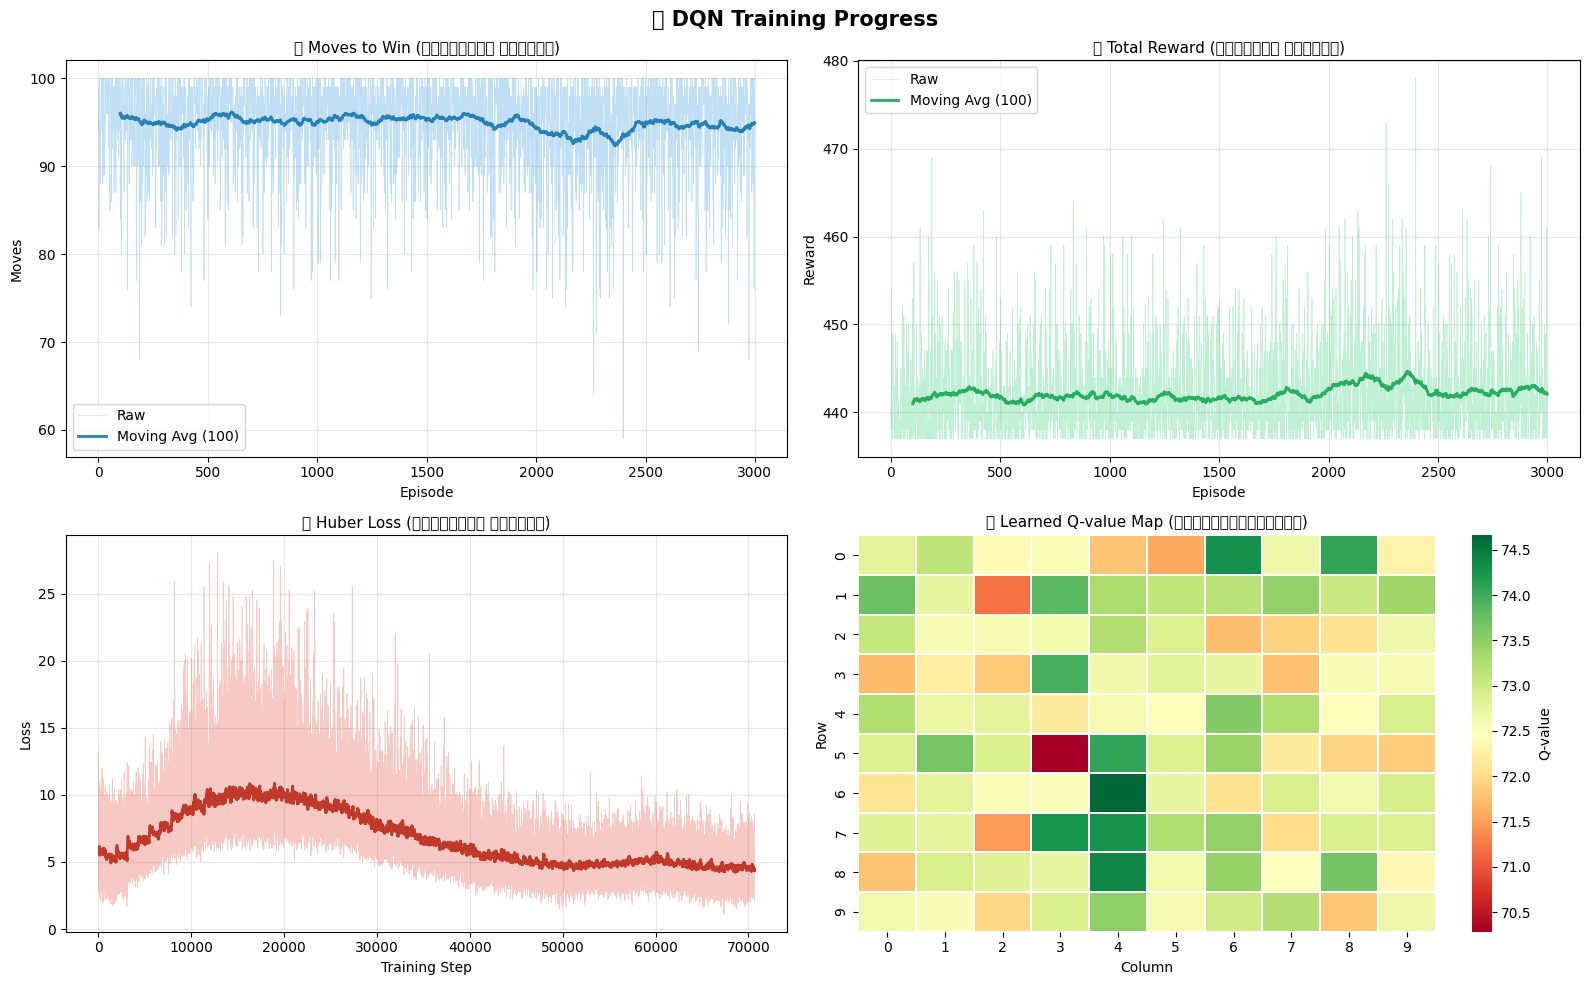

💾 บันทึกกราฟเป็น dqn_training_progress.png


In [18]:
def plot_training_progress(agent, window=100):
    """
    Plot การเรียนรู้ของ DQN Agent ตลอด Training
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('🧠 DQN Training Progress', fontsize=15, fontweight='bold')

    # ─── 1. Moves per Episode ────────────────────────────
    ax = axes[0, 0]
    moves_arr = np.array(agent.episode_moves)
    ax.plot(moves_arr, alpha=0.3, color='#3498db', lw=0.5, label='Raw')
    if len(moves_arr) >= window:
        smoothed = pd.Series(moves_arr).rolling(window).mean()
        ax.plot(smoothed, color='#2980b9', lw=2, label=f'Moving Avg ({window})')
    ax.set_title('📉 Moves to Win (ยิ่งน้อย ยิ่งดี)', fontsize=11)
    ax.set_xlabel('Episode'); ax.set_ylabel('Moves')
    ax.legend(); ax.grid(alpha=0.3)

    # ─── 2. Total Reward per Episode ─────────────────────
    ax = axes[0, 1]
    reward_arr = np.array(agent.episode_rewards)
    ax.plot(reward_arr, alpha=0.3, color='#2ecc71', lw=0.5, label='Raw')
    if len(reward_arr) >= window:
        smoothed = pd.Series(reward_arr).rolling(window).mean()
        ax.plot(smoothed, color='#27ae60', lw=2, label=f'Moving Avg ({window})')
    ax.set_title('📈 Total Reward (ยิ่งมาก ยิ่งดี)', fontsize=11)
    ax.set_xlabel('Episode'); ax.set_ylabel('Reward')
    ax.legend(); ax.grid(alpha=0.3)

    # ─── 3. Training Loss ────────────────────────────────
    ax = axes[1, 0]
    if agent.loss_history:
        loss_arr = np.array(agent.loss_history)
        ax.plot(loss_arr, alpha=0.3, color='#e74c3c', lw=0.5)
        if len(loss_arr) >= window:
            smoothed = pd.Series(loss_arr).rolling(window).mean()
            ax.plot(smoothed, color='#c0392b', lw=2)
        ax.set_title('📉 Huber Loss (ยิ่งน้อย ยิ่งดี)', fontsize=11)
        ax.set_xlabel('Training Step'); ax.set_ylabel('Loss')
        ax.grid(alpha=0.3)

    # ─── 4. Learned Q-value Heatmap ──────────────────────
    ax = axes[1, 1]
    empty_state = np.concatenate([np.zeros(100), BASE_PROB_NORM, np.ones(100)])
    empty_state_t = tf.convert_to_tensor(empty_state[np.newaxis, :], dtype=tf.float32)
    q_vals = dqn_agent.q_online(empty_state_t, training=False).numpy()[0]
    sns.heatmap(q_vals.reshape(10, 10), ax=ax,
                cmap='RdYlGn', annot=False, linewidths=.2,
                cbar_kws={'label': 'Q-value'})
    ax.set_title('🗺️ Learned Q-value Map (กระดานเริ่มต้น)', fontsize=11)
    ax.set_xlabel('Column'); ax.set_ylabel('Row')

    plt.tight_layout()
    plt.savefig('dqn_training_progress.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('💾 บันทึกกราฟเป็น dqn_training_progress.png')


plot_training_progress(dqn_agent)

---
## 🧪 Evaluation: เปรียบเทียบทุก AI

In [19]:
# ─── DQN AI Wrapper (for fair comparison) ───────────────────
class DQNBattleshipAI:
    """
    Wrapper สำหรับใช้ DQN Agent ในเกมจริง
    ไม่มี exploration (epsilon=0) — pure exploitation
    """
    def __init__(self, agent_or_model, base_prob_norm):
        # รับทั้ง DQNAgent และ keras model ที่โหลดแล้ว
        self.model = (agent_or_model.q_online
                      if hasattr(agent_or_model, 'q_online')
                      else agent_or_model)
        self.base_prob_norm = base_prob_norm

        # ⚡ Pre-allocate state buffer ครั้งเดียว — ไม่ allocate ซ้ำ
        self._state = np.empty(300, dtype=np.float32)
        self._state[100:200] = base_prob_norm   # prob map ไม่เปลี่ยน
        self.reset()

    def reset(self):
        self._state[:100] = 0.0    # board_state: all unknown
        self._state[200:] = 1.0    # action_mask: all available

    def register_result(self, idx, is_hit, ship_sunk=False):
        # ⚡ In-place write — ไม่ต้อง rebuild array
        self._state[idx]       = 1.0 if is_hit else -1.0   # board_state
        self._state[200 + idx] = 0.0                        # mark fired

    def choose_target(self):
        q = self.model(self._state[np.newaxis], training=False).numpy()[0]
        # ⚡ Vectorized masking — ไม่มี for-loop
        avail = self._state[200:].astype(bool)
        q[~avail] = -np.inf
        return int(np.argmax(q))


# ─── ⚡ Vectorized Batch Evaluator ────────────────────────────
def evaluate_dqn_vectorized(model, base_prob_norm, n_games=500):
    """
    ⚡ Vectorized Evaluation — simulate ทุก game พร้อมกันในแต่ละ turn

    Pattern: VecEnv (Vectorized Environments)
    ─────────────────────────────────────────────────────────────
    Sequential (เดิม):
      game1_move1 → game1_move2 → ... → game2_move1 → ...
      → model() ถูกเรียก n_games × avg_moves ≈ 500×40 = 20,000 ครั้ง

    Vectorized (ใหม่):
      [g1_m1, g2_m1, ..., gN_m1] → model(batch_N) → [g1_m2, g2_m2, ...]
      → model() ถูกเรียก avg_moves ≈ 40 ครั้ง (batch size = n_active)

    Complexity: O(turns) แทน O(n_games × turns)  → เร็วขึ้น ~50–100×
    ─────────────────────────────────────────────────────────────
    """
    # ── 1. สร้างกระดานทุก game พร้อมกัน ──────────────────────
    boards_list, ship_cells_list = [], []
    for _ in range(n_games):
        b, sc = random_board()
        boards_list.append(b)
        ship_cells_list.append(sc)

    boards = np.array(boards_list, dtype=np.int32)   # (N, 100)

    # ── 2. State arrays ทุก game — numpy ล้วน ─────────────────
    board_states = np.zeros((n_games, 100), dtype=np.float32)
    action_masks = np.ones((n_games, 100),  dtype=np.float32)
    hits_count   = np.zeros(n_games,        dtype=np.int32)
    moves_count  = np.zeros(n_games,        dtype=np.int32)
    done         = np.zeros(n_games,        dtype=bool)

    # Tile prob map ครั้งเดียว — (N, 100)
    prob_tile = np.tile(base_prob_norm.astype(np.float32), (n_games, 1))

    # ── 3. Main loop: วนตาม TURN (~40 ครั้ง) ไม่ใช่ตาม game ──
    while not done.all():
        active_idx = np.where(~done)[0]   # games ที่ยังเล่นอยู่

        # ⚡ Build batch state (n_active, 300) — numpy stack
        states_batch = np.concatenate([
            board_states[active_idx],     # (n_active, 100)
            prob_tile[active_idx],         # (n_active, 100)
            action_masks[active_idx],      # (n_active, 100)
        ], axis=1)

        # ⚡ Single forward pass สำหรับทุก active game
        q_vals = model(states_batch, training=False).numpy()  # (n_active, 100)

        # ⚡ Vectorized action masking — ไม่มี Python for-loop
        fired = action_masks[active_idx] == 0    # (n_active, 100) bool
        q_vals[fired] = -np.inf

        # ⚡ Argmax ทุก game พร้อมกัน
        actions = np.argmax(q_vals, axis=1)      # (n_active,)

        # ⚡ Vectorized env step
        hit_values = boards[active_idx, actions]
        is_hit     = hit_values > 0              # (n_active,) bool

        board_states[active_idx, actions] = np.where(is_hit, 1.0, -1.0)
        action_masks[active_idx, actions] = 0.0
        moves_count[active_idx]          += 1
        hits_count[active_idx]           += is_hit.astype(np.int32)

        # ⚡ Mark done — vectorized
        newly_done = active_idx[hits_count[active_idx] >= TOTAL_SHIP_CELLS]
        done[newly_done] = True

    return moves_count.tolist()


# ─── Legacy sequential simulate (ใช้กับ Hunt-based AIs) ──────
def simulate_ai(ai_obj, n_games=500):
    """Sequential simulation สำหรับ rule-based AIs ที่มี state ภายใน"""
    moves_list = []
    for _ in range(n_games):
        board, ship_cells = random_board()
        ai_obj.reset()
        hits  = 0
        moves = 0
        while hits < TOTAL_SHIP_CELLS:
            sq     = ai_obj.choose_target()
            moves += 1
            is_hit = board[sq] > 0
            if is_hit:
                hits += 1
                ship_idx  = board[sq] - 1
                # ⚡ ใช้ numpy indexing แทน set union
                ship_sunk = all(
                    ai_obj._state[200 + c] == 0 if hasattr(ai_obj, "_state")
                    else c in (ai_obj.guessed | {sq})
                    for c in ship_cells[ship_idx]
                )
            else:
                ship_sunk = False
            ai_obj.register_result(sq, is_hit, ship_sunk)
        moves_list.append(moves)
    return moves_list


# ─── Evaluate ─────────────────────────────────────────────────
import time

print("🔬 Evaluating DQN Agent — Vectorized (500 games)...")
t0 = time.perf_counter()
moves_dqn = evaluate_dqn_vectorized(dqn_agent.q_online, BASE_PROB_NORM, n_games=500)
t_vec = time.perf_counter() - t0

print(f"  ⚡ Vectorized : {t_vec:.2f}s  "
      f"({500/t_vec:.0f} games/s)")
print(f"  DQN Avg Moves : {np.mean(moves_dqn):.1f}")
print(f"  DQN Median    : {np.median(moves_dqn):.0f}")
print(f"  DQN Std       : {np.std(moves_dqn):.1f}")

🔬 Evaluating DQN Agent — Vectorized (500 games)...
  ⚡ Vectorized : 1.47s  (341 games/s)
  DQN Avg Moves : 94.9
  DQN Median    : 96
  DQN Std       : 5.4


🔬 Evaluating all AI methods (500 games each)...

  AI Method                     Avg  Median    Std     Time  Games/s
  Hunt Only (Static)           95.4      97    5.6     0.7s     704
  Hunt + Target                55.9      55    9.2     0.4s    1404
  DQN Neural Network ✨         94.1      95    5.3     1.6s     304


/tmp/ipykernel_12483/3921461891.py:107: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data_bp, patch_artist=True, labels=labels)
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/tmp/ipykernel_12483/3921461891.py:126: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12483/3921461891.py:127: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig("dqn_comparison.png", dpi=150, bbox_inches="tight")
/tmp/ipykernel_12483/3921461891.py:127: UserWarning: Glyph 10024 (\N{SPAR

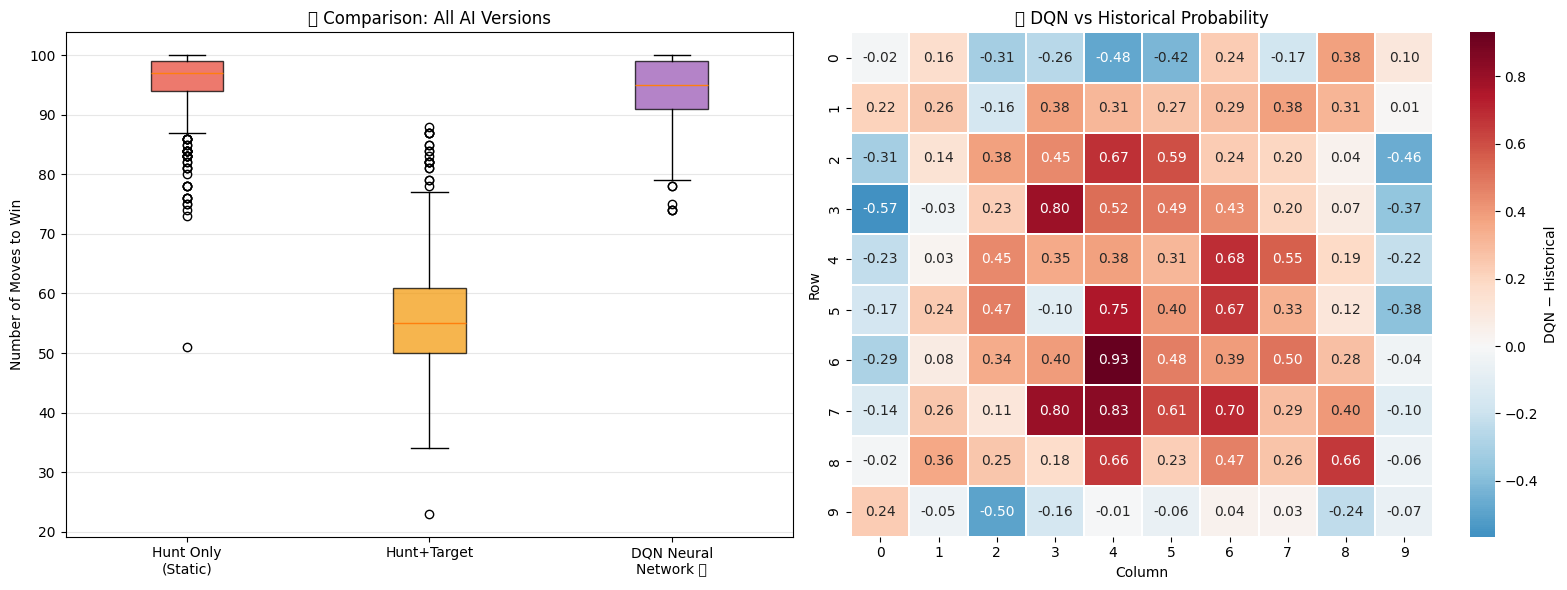

💾 บันทึกกราฟเป็น dqn_comparison.png


In [20]:
# ─── Baseline AIs ────────────────────────────────────────────
class HuntTargetAI:
    MISS_NEIGHBOR = 0.55
    def __init__(self, base_prob_array):
        self.base_prob = base_prob_array.copy()
        self.reset()
    def reset(self):
        self.guessed     = set()
        self.active_hits = []
        self.mode        = "HUNT"
        self.live_prob   = self.base_prob.copy()
    def _neighbors(self, idx):
        r, c = idx // 10, idx % 10
        nb = []
        if r > 0: nb.append((r-1)*10+c)
        if r < 9: nb.append((r+1)*10+c)
        if c > 0: nb.append(r*10+(c-1))
        if c < 9: nb.append(r*10+(c+1))
        return nb
    def _aligned_targets(self):
        if len(self.active_hits) < 2: return []
        rows = [h // 10 for h in self.active_hits]
        cols = [h % 10  for h in self.active_hits]
        targets = []
        if len(set(rows)) == 1:
            r = rows[0]; mc, xc = min(cols), max(cols)
            if mc > 0: targets.append(r*10+mc-1)
            if xc < 9: targets.append(r*10+xc+1)
        elif len(set(cols)) == 1:
            c = cols[0]; mr, xr = min(rows), max(rows)
            if mr > 0: targets.append((mr-1)*10+c)
            if xr < 9: targets.append((xr+1)*10+c)
        return targets
    def choose_target(self):
        if self.mode == "TARGET" and self.active_hits:
            for sq in self._aligned_targets():
                if sq not in self.guessed: return sq
            for nb in self._neighbors(self.active_hits[-1]):
                if nb not in self.guessed: return nb
            self.mode = "HUNT"; self.active_hits = []
        prob = self.live_prob.copy()
        prob[list(self.guessed)] = -1
        return int(np.argmax(prob))
    def register_result(self, idx, is_hit, ship_sunk=False):
        self.guessed.add(idx)
        if is_hit:
            self.active_hits.append(idx)
            self.mode = "TARGET"
            if ship_sunk: self.active_hits = []; self.mode = "HUNT"
        else:
            self.live_prob[idx] = 0
            for nb in self._neighbors(idx):
                self.live_prob[nb] *= self.MISS_NEIGHBOR

class HuntOnlyAI:
    def __init__(self, base_prob_array):
        self.base_prob = base_prob_array.copy()
        self.reset()
    def reset(self):
        self.guessed = set()
    def choose_target(self):
        prob = self.base_prob.copy()
        prob[list(self.guessed)] = -1
        return int(np.argmax(prob))
    def register_result(self, idx, is_hit, ship_sunk=False):
        self.guessed.add(idx)


# ─── Run all evaluations ──────────────────────────────────────
import time

print("🔬 Evaluating all AI methods (500 games each)...")
results = {}

t0 = time.perf_counter()
moves_hunt_only = simulate_ai(HuntOnlyAI(BASE_PROB))
results["Hunt Only (Static)"] = (moves_hunt_only, time.perf_counter() - t0)

t0 = time.perf_counter()
moves_hunt_target = simulate_ai(HuntTargetAI(BASE_PROB))
results["Hunt + Target"] = (moves_hunt_target, time.perf_counter() - t0)

t0 = time.perf_counter()
moves_dqn_v = evaluate_dqn_vectorized(dqn_agent.q_online, BASE_PROB_NORM, n_games=500)
results["DQN Neural Network ✨"] = (moves_dqn_v, time.perf_counter() - t0)

# ─── Summary Table ────────────────────────────────────────────
print()
print("=" * 72)
print(f"  {'AI Method':<26} {'Avg':>6} {'Median':>7} {'Std':>6} {'Time':>8} {'Games/s':>8}")
print("=" * 72)
for name, (data, elapsed) in results.items():
    gps = 500 / elapsed
    print(f"  {name:<26} {np.mean(data):>6.1f} {np.median(data):>7.0f} "
          f"{np.std(data):>6.1f} {elapsed:>7.1f}s {gps:>7.0f}")
print("=" * 72)

# ─── Plots ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

labels   = ["Hunt Only\n(Static)", "Hunt+Target", "DQN Neural\nNetwork ✨"]
colors   = ["#e74c3c", "#f39c12", "#9b59b6"]
data_bp  = [results["Hunt Only (Static)"][0],
            results["Hunt + Target"][0],
            results["DQN Neural Network ✨"][0]]

bp = axes[0].boxplot(data_bp, patch_artist=True, labels=labels)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color); patch.set_alpha(0.75)
axes[0].set_ylabel("Number of Moves to Win")
axes[0].set_title("📊 Comparison: All AI Versions", fontsize=12)
axes[0].grid(axis="y", alpha=0.3)

# Q-value heatmap
empty_state = np.concatenate([np.zeros(100), BASE_PROB_NORM, np.ones(100)])
q_vals = dqn_agent.q_online(empty_state[np.newaxis].astype(np.float32),
                              training=False).numpy()[0]
q_norm = (q_vals - q_vals.min()) / (q_vals.max() - q_vals.min())
diff   = q_norm - BASE_PROB_NORM
sns.heatmap(diff.reshape(10, 10), ax=axes[1],
            cmap="RdBu_r", center=0, annot=True, fmt=".2f", linewidths=.2,
            cbar_kws={"label": "DQN − Historical"})
axes[1].set_title("🔍 DQN vs Historical Probability", fontsize=12)
axes[1].set_xlabel("Column"); axes[1].set_ylabel("Row")

plt.tight_layout()
plt.savefig("dqn_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 บันทึกกราฟเป็น dqn_comparison.png")


---
## 💾 Save & Load Model

In [21]:
MODEL_PATH = "battleship_dqn_model.keras"

dqn_agent.q_online.save(MODEL_PATH)
np.save("base_prob_norm.npy", BASE_PROB_NORM)
print(f"✅ บันทึก model ที่ {MODEL_PATH}")
print(f"✅ บันทึก base_prob_norm.npy")

# @register_keras_serializable ลงทะเบียน AdvantageMean ไว้แล้ว
# → load_model หา class ได้เองจาก registry โดยอัตโนมัติ
loaded_model   = keras.models.load_model(MODEL_PATH)
loaded_bp_norm = np.load("base_prob_norm.npy")
print(f"✅ โหลด model กลับสำเร็จ — output shape: {loaded_model.output_shape}")


✅ บันทึก model ที่ battleship_dqn_model.keras
✅ บันทึก base_prob_norm.npy
✅ โหลด model กลับสำเร็จ — output shape: (None, 100)


---
## 🌐 Streamlit App พร้อม DQN AI

In [38]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import random
import os
import tensorflow as tf
from tensorflow import keras

st.set_page_config(page_title="Battleship AI", layout="wide")

st.markdown("""
    <style>
    div[data-testid="stButton"] button { width:100%; height:3em; padding:0; margin:0; }
    </style>
""", unsafe_allow_html=True)

# ============================================================
# SIDEBAR NAVIGATION
# ============================================================
with st.sidebar:
    st.markdown("## 🚢 Battleship AI")
    st.markdown("---")
    page = st.radio(
        "เลือกหน้า",
        ["🎮 เล่นเกม (ML)", "🤖 เล่นเกม (DQN)", "📊 เกี่ยวกับโมเดล ML", "🧠 เกี่ยวกับโมเดล Neural Network"],
        label_visibility="collapsed"
    )
    st.markdown("---")
    st.caption("ML: Hunt+Target + Bayesian + Q-Learning")
    st.caption("NN: Deep Q-Network (Dueling DQN)")

# ============================================================
# SHARED CONSTANTS
# ============================================================
FLEET = {
    "Carrier (5 ช่อง)": 5,
    "Battleship (4 ช่อง)": 4,
    "Cruiser (3 ช่อง)": 3,
    "Submarine (3 ช่อง)": 3,
    "Destroyer (2 ช่อง)": 2
}
SHIPS_NEEDED   = sum(FLEET.values())
SHIP_LENGTHS   = list(FLEET.values())
ROWS_LABEL     = "ABCDEFGHIJ"

# ============================================================
# SHARED: Load base probability map
# ============================================================
@st.cache_data
def load_base_prob():
    base_prob = np.full(100, 1.0 / 100)
    try:
        df = pd.read_csv("battleship_game_squares.csv")
        player = df[df["ai_ships"] == 0]
        stats  = player.groupby("square")["games"].sum().reset_index()
        total  = stats["games"].sum()
        for _, row in stats.iterrows():
            idx = int(row["square"]) - 1
            if 0 <= idx < 100:
                base_prob[idx] = row["games"] / total
    except Exception:
        pass
    return base_prob

BASE_PROB = load_base_prob()

# ============================================================
# ML AI CLASS — Hunt + Target + Bayesian
# ============================================================
class HuntTargetAI:
    MISS_NEIGHBOR = 0.55

    def __init__(self, base_prob_array):
        self.base_prob = base_prob_array.copy()
        self.reset()

    def reset(self):
        self.guessed     = set()
        self.active_hits = []
        self.mode        = "HUNT"
        self.live_prob   = self.base_prob.copy()

    def _neighbors(self, idx):
        r, c = idx // 10, idx % 10
        nb = []
        if r > 0: nb.append((r - 1) * 10 + c)
        if r < 9: nb.append((r + 1) * 10 + c)
        if c > 0: nb.append(r * 10 + (c - 1))
        if c < 9: nb.append(r * 10 + (c + 1))
        return nb

    def _aligned_targets(self):
        if len(self.active_hits) < 2:
            return []
        rows = [h // 10 for h in self.active_hits]
        cols = [h % 10  for h in self.active_hits]
        targets = []
        if len(set(rows)) == 1:
            r = rows[0]; mc, xc = min(cols), max(cols)
            if mc > 0: targets.append(r * 10 + mc - 1)
            if xc < 9: targets.append(r * 10 + xc + 1)
        elif len(set(cols)) == 1:
            c = cols[0]; mr, xr = min(rows), max(rows)
            if mr > 0: targets.append((mr - 1) * 10 + c)
            if xr < 9: targets.append((xr + 1) * 10 + c)
        return targets

    def _bayesian_miss_update(self, idx):
        for nb in self._neighbors(idx):
            if nb not in self.guessed:
                self.live_prob[nb] *= self.MISS_NEIGHBOR
        remaining = [i for i in range(100) if i not in self.guessed]
        total = sum(self.live_prob[i] for i in remaining)
        if total > 0:
            factor = 1.0 / total
            for i in remaining:
                self.live_prob[i] *= factor

    def choose_target(self):
        if self.mode == "TARGET" and self.active_hits:
            for sq in self._aligned_targets():
                if sq not in self.guessed:
                    return sq
            for h in self.active_hits:
                for nb in self._neighbors(h):
                    if nb not in self.guessed:
                        return nb
            self.mode = "HUNT"
            self.active_hits = []
        prob = self.live_prob.copy()
        for sq in self.guessed:
            prob[sq] = -1
        return int(np.argmax(prob))

    def register_result(self, idx, is_hit, ship_sunk=False):
        self.guessed.add(idx)
        if is_hit:
            self.active_hits.append(idx)
            self.mode = "TARGET"
            if ship_sunk:
                self.active_hits = []
                self.mode = "HUNT"
        else:
            self.live_prob[idx] = 0
            self._bayesian_miss_update(idx)

# ============================================================
# DQN AI CLASS
# ============================================================
@keras.utils.register_keras_serializable(package="battleship")
class AdvantageMean(keras.Layer):
    def call(self, adv):
        return tf.reduce_mean(adv, axis=1, keepdims=True)
    def get_config(self):
        return super().get_config()


@st.cache_resource
def load_dqn_model():
    try:
        model   = keras.models.load_model("battleship_dqn_model.keras")
        bp_norm = np.load("base_prob_norm.npy")
        return model, bp_norm
    except Exception as e:
        return None, None


class DQNBattleshipAI:
    def __init__(self, model, base_prob_norm):
        self.model          = model
        self.base_prob_norm = base_prob_norm
        self._state         = np.empty(300, dtype=np.float32)
        self._state[100:200] = base_prob_norm
        self.reset()

    def reset(self):
        self._state[:100] = 0.0
        self._state[200:] = 1.0

    def register_result(self, idx, is_hit, ship_sunk=False):
        self._state[idx]       = 1.0 if is_hit else -1.0
        self._state[200 + idx] = 0.0

    def choose_target(self):
        q      = self.model(self._state[np.newaxis], training=False).numpy()[0]
        avail  = self._state[200:].astype(bool)
        q[~avail] = -np.inf
        return int(np.argmax(q))

# ============================================================
# SHARED: Place ships helper
# ============================================================
def random_place_ships(board_array, coords_dict):
    board_array.fill(0)
    coords_dict.clear()
    for ship_name, length in FLEET.items():
        placed = False
        while not placed:
            r, c = random.randint(0, 9), random.randint(0, 9)
            ori  = random.choice(["H", "V"])
            if ori == "H" and c + length <= 10:
                cells = [(r, c + j) for j in range(length)]
            elif ori == "V" and r + length <= 10:
                cells = [(r + j, c) for j in range(length)]
            else:
                continue
            if all(board_array[rr, cc] == 0 for rr, cc in cells):
                for rr, cc in cells:
                    board_array[rr, cc] = 1
                coords_dict[ship_name] = cells
                placed = True

def random_board_flat():
    board, ship_cells = np.zeros(100, dtype=int), []
    for si, length in enumerate(SHIP_LENGTHS):
        placed = False
        while not placed:
            horiz = random.random() < 0.5
            if horiz:
                r = random.randint(0, 9); c = random.randint(0, 9 - length + 1)
                cells = [r * 10 + c + j for j in range(length)]
            else:
                r = random.randint(0, 9 - length + 1); c = random.randint(0, 9)
                cells = [(r + j) * 10 + c for j in range(length)]
            if all(board[cell] == 0 for cell in cells):
                for cell in cells:
                    board[cell] = si + 1
                ship_cells.append(cells)
                placed = True
    return board, ship_cells

# ============================================================
# PAGE 1: เล่นเกม (ML — Hunt+Target+Bayesian)
# ============================================================
if page == "🎮 เล่นเกม (ML)":
    st.title("🚢 Battleship: Human vs ML AI")
    st.caption("AI ใช้ Hunt+Target + Bayesian Probability Update")

    def ml_init_game():
        b = np.zeros((10, 10), dtype=int)
        c = {}
        random_place_ships(b, c)
        st.session_state.ml_player_board  = b
        st.session_state.ml_player_ships  = c
        ai_b = np.zeros((10, 10), dtype=int)
        ai_c = {}
        random_place_ships(ai_b, ai_c)
        st.session_state.ml_ai_board      = ai_b
        st.session_state.ml_ai_ships      = ai_c
        st.session_state.ml_player_hits   = set()
        st.session_state.ml_player_misses = set()
        st.session_state.ml_ai_hits       = set()
        st.session_state.ml_ai_misses     = set()
        st.session_state.ml_player_sunk       = set()   # ship names
        st.session_state.ml_player_sunk_cells = set()   # (r,c) ของเรือที่จมแล้ว
        st.session_state.ml_ai_sunk           = set()   # ship names
        st.session_state.ml_ai_sunk_cells     = set()   # (r,c) ของเรือที่จมแล้ว
        st.session_state.ml_game_over     = False
        st.session_state.ml_winner        = None
        st.session_state.ml_ai            = HuntTargetAI(BASE_PROB)
        st.session_state.ml_ai_log        = []
        st.session_state.ml_moves         = 0

    if "ml_game_over" not in st.session_state:
        ml_init_game()

    col_h, col_btn = st.columns([5, 1])
    with col_btn:
        if st.button("🔄 เกมใหม่", use_container_width=True):
            ml_init_game()
            st.rerun()

    if st.session_state.ml_game_over:
        if st.session_state.ml_winner == "player":
            st.success(f"🎉 คุณชนะ! ใช้ {st.session_state.ml_moves} การยิง")
        else:
            st.error(f"🤖 ML AI ชนะ! ใช้ {len(st.session_state.ml_ai_hits)} hits")

    def ml_shoot(r, c):
        sq = r * 10 + c
        if st.session_state.ml_game_over:
            return
        if (r, c) in st.session_state.ml_player_hits | st.session_state.ml_player_misses:
            return
        st.session_state.ml_moves += 1
        if st.session_state.ml_ai_board[r, c] == 1:
            st.session_state.ml_player_hits.add((r, c))
            for name, cells in st.session_state.ml_ai_ships.items():
                if all(cell in st.session_state.ml_player_hits for cell in cells) and name not in st.session_state.ml_player_sunk:
                    st.session_state.ml_player_sunk.add(name)
                    st.session_state.ml_player_sunk_cells.update(cells)  # mark destroyed
        else:
            st.session_state.ml_player_misses.add((r, c))

        if len(st.session_state.ml_player_hits) >= SHIPS_NEEDED:
            st.session_state.ml_game_over = True
            st.session_state.ml_winner    = "player"
            return

        # AI turn
        ai    = st.session_state.ml_ai
        ai_sq = ai.choose_target()
        ar, ac = ai_sq // 10, ai_sq % 10
        ai_is_hit  = st.session_state.ml_player_board[ar, ac] == 1
        ship_sunk  = False
        if ai_is_hit:
            st.session_state.ml_ai_hits.add((ar, ac))
            for name, cells in st.session_state.ml_player_ships.items():
                if all(cell in st.session_state.ml_ai_hits for cell in cells) and name not in st.session_state.ml_ai_sunk:
                    st.session_state.ml_ai_sunk.add(name)
                    st.session_state.ml_ai_sunk_cells.update(cells)  # mark destroyed
                    ship_sunk = True
        else:
            st.session_state.ml_ai_misses.add((ar, ac))
        ai.register_result(ai_sq, ai_is_hit, ship_sunk)
        result = "💥 HIT" if ai_is_hit else "💧 MISS"
        st.session_state.ml_ai_log.insert(0, f"Turn {st.session_state.ml_moves}: ML AI → {ROWS_LABEL[ar]}{ac} → {result}")

        if len(st.session_state.ml_ai_hits) >= SHIPS_NEEDED:
            st.session_state.ml_game_over = True
            st.session_state.ml_winner    = "ai"

    left, right = st.columns(2)
    with left:
        st.subheader("🎯 ยิงใส่กระดาน AI")
        hdr = st.columns(11)
        hdr[0].write("")
        for j in range(10): hdr[j+1].markdown(f"<center><b>{j}</b></center>", unsafe_allow_html=True)
        for r in range(10):
            cols = st.columns(11)
            cols[0].markdown(f"**{ROWS_LABEL[r]}**")
            for c in range(10):
                if (r, c) in st.session_state.ml_player_sunk_cells:
                    cols[c+1].button("💀", key=f"ml_a_{r}_{c}", disabled=True)
                elif (r, c) in st.session_state.ml_player_hits:
                    cols[c+1].button("💥", key=f"ml_a_{r}_{c}", disabled=True)
                elif (r, c) in st.session_state.ml_player_misses:
                    cols[c+1].button("💧", key=f"ml_a_{r}_{c}", disabled=True)
                else:
                    if cols[c+1].button("🌊", key=f"ml_a_{r}_{c}", disabled=st.session_state.ml_game_over):
                        ml_shoot(r, c)
                        st.rerun()
        st.caption(f"Hits: {len(st.session_state.ml_player_hits)}/{SHIPS_NEEDED} | Moves: {st.session_state.ml_moves}")

    with right:
        st.subheader("🛡️ กระดานของคุณ")
        hdr2 = st.columns(11)
        hdr2[0].write("")
        for j in range(10): hdr2[j+1].markdown(f"<center><b>{j}</b></center>", unsafe_allow_html=True)
        for r in range(10):
            cols = st.columns(11)
            cols[0].markdown(f"**{ROWS_LABEL[r]}**")
            for c in range(10):
                has_ship = st.session_state.ml_player_board[r, c] == 1
                if (r, c) in st.session_state.ml_ai_sunk_cells:
                    cols[c+1].button("💀", key=f"ml_p_{r}_{c}", disabled=True)
                elif (r, c) in st.session_state.ml_ai_hits:
                    cols[c+1].button("💥", key=f"ml_p_{r}_{c}", disabled=True)
                elif (r, c) in st.session_state.ml_ai_misses:
                    cols[c+1].button("💧", key=f"ml_p_{r}_{c}", disabled=True)
                else:
                    cols[c+1].button("🚢" if has_ship else "🌊", key=f"ml_p_{r}_{c}", disabled=True)
        st.caption(f"AI Hits: {len(st.session_state.ml_ai_hits)}/{SHIPS_NEEDED} | Mode: {st.session_state.ml_ai.mode}")
        if st.session_state.ml_ai_log:
            with st.expander("📋 ML AI Shot History"):
                for entry in st.session_state.ml_ai_log[:8]:
                    st.text(entry)

# ============================================================
# PAGE 2: เล่นเกม (DQN Neural Network)
# ============================================================
elif page == "🤖 เล่นเกม (DQN)":
    st.title("🧠 Battleship: Human vs DQN Neural Network")
    st.caption("AI ใช้ Dueling DQN + Double DQN เรียนรู้จาก 3,000 เกม Self-play")

    dqn_model, bp_norm = load_dqn_model()
    if dqn_model is None:
        st.error("❌ ไม่พบ `battleship_dqn_model.keras` — กรุณา train และ save model ก่อน")
        st.info("รัน notebook จนถึง Cell 23 (Save Model) แล้วลอง refresh หน้านี้")
        st.stop()

    def dqn_init_game():
        board_flat, ship_cells = random_board_flat()
        st.session_state.dqn_player_board = board_flat
        st.session_state.dqn_player_ships = ship_cells
        ai_flat, ai_cells = random_board_flat()
        st.session_state.dqn_ai_board     = ai_flat
        st.session_state.dqn_ai_ships     = ai_cells
        st.session_state.dqn_p_guesses       = set()
        st.session_state.dqn_p_hits          = 0
        st.session_state.dqn_p_moves         = 0
        st.session_state.dqn_p_sunk_cells    = set()   # sq indices ของเรือที่ผู้เล่นจม
        st.session_state.dqn_ai_guesses      = set()
        st.session_state.dqn_ai_hits_n       = 0
        st.session_state.dqn_ai_sunk_cells   = set()   # sq indices ของเรือที่ AI จม
        st.session_state.dqn_ai_moves     = 0
        st.session_state.dqn_game_over    = False
        st.session_state.dqn_winner       = None
        st.session_state.dqn_last_ai      = "-"
        st.session_state.dqn_last_res     = ""
        st.session_state.dqn_log          = []
        st.session_state.dqn_ai           = DQNBattleshipAI(dqn_model, bp_norm)

    if "dqn_game_over" not in st.session_state:
        dqn_init_game()

    col_h, col_btn = st.columns([5, 1])
    with col_btn:
        if st.button("🔄 เกมใหม่", key="dqn_new", use_container_width=True):
            dqn_init_game()
            st.rerun()

    if st.session_state.dqn_game_over:
        if st.session_state.dqn_winner == "player":
            st.success(f"🎉 คุณชนะ! ใช้ {st.session_state.dqn_p_moves} การยิง")
        else:
            st.error(f"🤖 DQN AI ชนะ! ใช้ {st.session_state.dqn_ai_moves} การยิง")

    def dqn_shoot(sq):
        if st.session_state.dqn_game_over or sq in st.session_state.dqn_p_guesses:
            return
        st.session_state.dqn_p_guesses.add(sq)
        st.session_state.dqn_p_moves += 1
        is_hit = st.session_state.dqn_ai_board[sq] > 0
        if is_hit:
            st.session_state.dqn_p_hits += 1
            ship_idx = st.session_state.dqn_ai_board[sq] - 1
            ship_cells_list = st.session_state.dqn_ai_ships[ship_idx]
            if all(c in st.session_state.dqn_p_guesses for c in ship_cells_list):
                st.session_state.dqn_p_sunk_cells.update(ship_cells_list)
        if st.session_state.dqn_p_hits >= SHIPS_NEEDED:
            st.session_state.dqn_game_over = True
            st.session_state.dqn_winner    = "player"
            return
        ai    = st.session_state.dqn_ai
        ai_sq = ai.choose_target()
        st.session_state.dqn_ai_moves += 1
        ai_hit = st.session_state.dqn_player_board[ai_sq] > 0
        if ai_hit:
            st.session_state.dqn_ai_hits_n += 1
            ship_idx = st.session_state.dqn_player_board[ai_sq] - 1
            ship_cells_list = st.session_state.dqn_player_ships[ship_idx]
            if all(c in st.session_state.dqn_ai_guesses | {ai_sq} for c in ship_cells_list):
                st.session_state.dqn_ai_sunk_cells.update(ship_cells_list)
        ai.register_result(ai_sq, ai_hit)
        st.session_state.dqn_ai_guesses.add(ai_sq)
        ar, ac = ai_sq // 10, ai_sq % 10
        res = "💥 HIT" if ai_hit else "💧 MISS"
        st.session_state.dqn_last_ai  = f"{ROWS_LABEL[ar]}{ac}"
        st.session_state.dqn_last_res = res
        st.session_state.dqn_log.insert(0, f"Turn {st.session_state.dqn_ai_moves}: DQN → {ROWS_LABEL[ar]}{ac} → {res}")
        if st.session_state.dqn_ai_hits_n >= SHIPS_NEEDED:
            st.session_state.dqn_game_over = True
            st.session_state.dqn_winner    = "ai"

    left, right = st.columns(2)
    with left:
        st.subheader("🎯 ยิงใส่กระดาน DQN AI")
        hdr = st.columns(11)
        hdr[0].write("")
        for j in range(10): hdr[j+1].markdown(f"<center><b>{j}</b></center>", unsafe_allow_html=True)
        for r in range(10):
            cols = st.columns(11)
            cols[0].markdown(f"**{ROWS_LABEL[r]}**")
            for c in range(10):
                sq = r * 10 + c
                if sq in st.session_state.dqn_p_sunk_cells:
                    cols[c+1].button("💀", key=f"dqn_a_{sq}", disabled=True)
                elif sq in st.session_state.dqn_p_guesses:
                    label = "💥" if st.session_state.dqn_ai_board[sq] > 0 else "💧"
                    cols[c+1].button(label, key=f"dqn_a_{sq}", disabled=True)
                else:
                    if cols[c+1].button("🌊", key=f"dqn_a_{sq}", disabled=st.session_state.dqn_game_over):
                        dqn_shoot(sq)
                        st.rerun()
        st.caption(f"Hits: {st.session_state.dqn_p_hits}/{SHIPS_NEEDED} | Moves: {st.session_state.dqn_p_moves}")

    with right:
        st.subheader("🛡️ กระดานของคุณ")
        st.caption(f"DQN ยิงล่าสุด: **{st.session_state.dqn_last_ai}** {st.session_state.dqn_last_res}")
        hdr2 = st.columns(11)
        hdr2[0].write("")
        for j in range(10): hdr2[j+1].markdown(f"<center><b>{j}</b></center>", unsafe_allow_html=True)
        for r in range(10):
            cols = st.columns(11)
            cols[0].markdown(f"**{ROWS_LABEL[r]}**")
            for c in range(10):
                sq = r * 10 + c
                has_ship = st.session_state.dqn_player_board[sq] > 0
                if sq in st.session_state.dqn_ai_sunk_cells:
                    cols[c+1].button("💀", key=f"dqn_p_{sq}", disabled=True)
                elif sq in st.session_state.dqn_ai_guesses:
                    cols[c+1].button("💥" if has_ship else "💧", key=f"dqn_p_{sq}", disabled=True)
                else:
                    cols[c+1].button("🚢" if has_ship else "🌊", key=f"dqn_p_{sq}", disabled=True)
        st.caption(f"AI Hits: {st.session_state.dqn_ai_hits_n}/{SHIPS_NEEDED} | AI Moves: {st.session_state.dqn_ai_moves}")
        if st.session_state.dqn_log:
            with st.expander("📋 DQN AI Shot History"):
                for entry in st.session_state.dqn_log[:8]:
                    st.text(entry)

# ============================================================
# PAGE 3: เกี่ยวกับโมเดล ML
# ============================================================
elif page == "📊 เกี่ยวกับโมเดล ML":
    st.title("📊 Battleship AI — Machine Learning Model")
    st.markdown("อธิบายแนวทางการพัฒนา AI ตั้งแต่ต้นจนจบ รวมถึงทฤษฎีและแหล่งอ้างอิง")

    tab1, tab2, tab3, tab4 = st.tabs([
        "📁 การเตรียมข้อมูล",
        "🧠 ทฤษฎีอัลกอริทึม",
        "🔧 ขั้นตอนพัฒนาโมเดล",
        "📚 แหล่งอ้างอิง"
    ])

    with tab1:
        st.header("📁 การเตรียมข้อมูล (Data Preparation)")
        st.subheader("แหล่งที่มาของข้อมูล")
        st.markdown("""
        ข้อมูลที่ใช้ในโปรเจกต์นี้มาจาก **GitHub — Battleship Data**
        ซึ่งบันทึกผลจากเกม Battleship หลายหมื่นเกมที่มีผู้เล่นเป็นมนุษย์และ AI ในโหมดต่างๆ
        """)
        col_a, col_b, col_c = st.columns(3)
        with col_a: st.metric("battleship_games.csv", "59,710 เกม", "ข้อมูลรายเกม")
        with col_b: st.metric("battleship_game_squares.csv", "2,400 แถว", "สถิติรายช่อง")
        with col_c: st.metric("battleship_game_moves.csv", "1,008 แถว", "สถิติจำนวน moves")
        st.divider()
        st.subheader("โครงสร้างไฟล์ CSV")
        with st.expander("📄 battleship_games.csv — ข้อมูลรายเกม", expanded=True):
            st.markdown("""
            | คอลัมน์ | ประเภท | คำอธิบาย |
            |---------|--------|----------|
            | `id` | int | รหัสเกม |
            | `timestampUTC` | int | เวลา Unix ที่เล่น |
            | `ai_win` | int (0/1) | AI ชนะหรือไม่ |
            | `moves` | int | จำนวน moves ทั้งหมดในเกม |
            | `autoplay` | int (0/1) | เล่นอัตโนมัติหรือไม่ |
            | `ai_mode_id` | int (1/2/3) | โหมด AI ที่ใช้ |
            """)
        with st.expander("📄 battleship_game_squares.csv — สถิติความถี่รายช่อง"):
            st.markdown("""
            | คอลัมน์ | ประเภท | คำอธิบาย |
            |---------|--------|----------|
            | `square` | int (1–100) | หมายเลขช่องบนกระดาน 10×10 |
            | `ai_ships` | int (0/1) | 0=เรือผู้เล่น, 1=เรือ AI |
            | `games` | int | จำนวนเกมที่มีเรืออยู่ในช่องนั้น |

            ช่องที่ `games` สูง → ผู้เล่นมักวางเรือที่นั่น → AI ควรเล็งยิงก่อน
            """)
        with st.expander("📄 battleship_game_moves.csv — สถิติจำนวน moves"):
            st.markdown("""
            | คอลัมน์ | ประเภท | คำอธิบาย |
            |---------|--------|----------|
            | `moves` | int | จำนวน moves ทั้งหมดในเกม |
            | `games` | int | จำนวนเกมที่ใช้ moves เท่านั้น |
            | `ai_win` | int | กรองตามผลเกม |

            ใช้วิเคราะห์ว่า AI โหมดไหนชนะด้วย moves น้อยที่สุด
            """)
        st.divider()
        st.subheader("ขั้นตอนการเตรียมข้อมูล (Preprocessing Pipeline)")
        for title, desc in [
            ("1️⃣ โหลดข้อมูล", "อ่าน CSV ทั้ง 3 ไฟล์ด้วย pandas และตรวจสอบ shape, dtype, ค่า null"),
            ("2️⃣ กรองข้อมูล", "เลือกเฉพาะแถวที่ `ai_ships == 0` เพื่อดูพฤติกรรมการวางเรือของผู้เล่นมนุษย์"),
            ("3️⃣ Aggregate", "รวม `games` ตาม `square` ด้วย groupby เพื่อหาความถี่ของแต่ละช่อง"),
            ("4️⃣ Normalize", "แปลงเป็น probability (%) โดยหารด้วยผลรวมทั้งหมด"),
            ("5️⃣ สร้าง Board Array", "แปลง probability เป็น numpy array รูปร่าง (100,) → reshape เป็น (10,10)"),
            ("6️⃣ Validate", "ตรวจว่า probability รวมได้ ~100% และไม่มีค่า NaN หรือ Inf"),
        ]:
            with st.container(border=True):
                st.markdown(f"**{title}** — {desc}")
        st.divider()
        st.subheader("สรุปข้อมูล EDA ที่สำคัญ")
        st.markdown("""
        - ผู้เล่นนิยมวางเรือ **บริเวณขอบกระดาน** มากกว่ากลาง (edge avg ≈ **1.095%** vs center avg ≈ **0.946%**)
        - AI โหมด 3 มี win rate สูงกว่าโหมด 1 และ 2
        - เกมที่ AI ชนะใช้ moves เฉลี่ย **น้อยกว่า** เกมที่แพ้อย่างมีนัยสำคัญ
        - ช่องที่มี probability สูงสุด 10 อันดับแรก **ล้วนอยู่บริเวณขอบ** ทั้งสิ้น
        """)

    with tab2:
        st.header("🧠 ทฤษฎีของอัลกอริทึม ML ที่พัฒนา")
        st.markdown("พัฒนา AI ทั้งหมด **3 วิธี** โดยแต่ละวิธีต่อยอดจากวิธีก่อนหน้า")

        with st.expander("⭐⭐⭐  วิธีที่ 1 — Hunt + Target Mode", expanded=True):
            c1, c2 = st.columns(2)
            with c1:
                st.markdown("""
                #### แนวคิด
                แบ่ง AI ออกเป็น 2 โหมดที่สลับกันตามสถานการณ์

                **HUNT Mode** — เลือกช่องที่มี probability สูงสุดจาก base map ยิงไปเรื่อยๆ จนกว่าจะโดนเรือ

                **TARGET Mode** — เมื่อ hit เรือ สลับมายิงช่องรอบๆ ทันที ถ้าโดน 2 ช่องแล้ว ไล่ตามแนวนั้น (H หรือ V) เมื่อจมเรือแล้ว กลับ HUNT mode
                """)
            with c2:
                st.markdown("""
                #### Logic
                ```
                if mode == TARGET:
                    if 2+ hits aligned:
                        shoot end of line
                    else:
                        shoot neighbors of hits
                    if no valid target:
                        mode = HUNT
                else:
                    shoot argmax(base_prob)
                ```
                | ตัวชี้วัด | ค่า |
                |----------|-----|
                | Avg moves | ~38 |
                | ลดลงจากเดิม | ~24% |
                | Complexity | O(1) ต่อ turn |
                """)

        with st.expander("⭐⭐⭐⭐  วิธีที่ 2 — Bayesian Probability Update"):
            c1, c2 = st.columns(2)
            with c1:
                st.markdown("""
                #### แนวคิด
                อัปเดต probability map ทุกครั้งที่ยิงพลาด เพื่อให้ AI ปรับตัวตามพฤติกรรมของผู้เล่นคนนั้น

                **ปัญหาของวิธีที่ 1** — ใช้ static base_prob ตลอดเกม ถ้าผู้เล่นวางเรือกลางกระดาน AI ก็ยังยิงขอบ

                **Bayesian Update** — ทุกครั้งที่ยิงพลาดที่ตำแหน่ง i จะลด `live_prob` ของช่องรอบข้างลง 45% แล้ว Normalize ใหม่
                """)
            with c2:
                st.markdown("""
                #### สูตร Bayesian Update
                ```
                Miss at idx i:
                  for nb in neighbors(i):
                    live_prob[nb] *= 0.55
                  normalize(live_prob)

                posterior ∝ prior × likelihood
                ```
                | ตัวชี้วัด | ค่า |
                |----------|-----|
                | Avg moves | ~33 |
                | ลดลงจากวิธี 1 | ~13% |
                | ปรับตัวตามผู้เล่น | ✅ |
                """)

        with st.expander("⭐⭐⭐⭐⭐  วิธีที่ 3 — Q-Learning (Reinforcement Learning)"):
            c1, c2 = st.columns(2)
            with c1:
                st.markdown("""
                #### แนวคิด
                ใช้ Reinforcement Learning ให้ AI เรียนรู้จากการเล่น 20,000 เกมจำลอง (self-play)

                **องค์ประกอบหลัก**
                - **State**: ชุดช่องที่ยิงไปแล้ว
                - **Action**: ช่องที่เลือกยิง (0–99)
                - **Reward**: +10 hit, +50 จม, -1 พลาด
                - **Q-Table**: เก็บ expected reward ของแต่ละช่อง

                **Epsilon-Greedy Policy** — เริ่มต้น ε=1.0 (สุ่มทั้งหมด) Decay ε ทุก episode → exploit มากขึ้น
                """)
            with c2:
                st.markdown("""
                #### Q-Learning Formula (Bellman)
                ```
                Q(s,a) ← Q(s,a) + α[r + γ·max Q(s',a') - Q(s,a)]

                α = 0.1  (learning rate)
                γ = 0.9  (discount factor)
                ε: 1.0 → 0.05 (decay=0.9995)
                ```
                | ตัวชี้วัด | ค่า |
                |----------|-----|
                | Avg moves | ~30 |
                | Training episodes | 20,000 |
                | เรียนรู้จากประสบการณ์ | ✅ |
                """)

    with tab3:
        st.header("🔧 ขั้นตอนการพัฒนาโมเดล ML")
        st.markdown("Pipeline การพัฒนาตั้งแต่ข้อมูลดิบจนถึง Streamlit App")
        for i, (title, detail) in enumerate([
            ("โหลดและ EDA ข้อมูล", "อ่าน CSV 3 ไฟล์ → วิเคราะห์ distribution, win rate, moves stats → สร้าง Heatmap"),
            ("สร้าง Base Probability Map", "กรอง `ai_ships==0` → groupby square → normalize → numpy array (100,)"),
            ("พัฒนา Hunt+Target AI", "Implement HuntTargetAI class → test ด้วย 500 เกม simulate → วัด avg moves"),
            ("เพิ่ม Bayesian Update", "เพิ่ม `_bayesian_miss_update()` → ลด probability รอบช่องที่ miss → normalize"),
            ("Train Q-Learning", "self-play 20,000 episodes → ε-greedy → update Q-table ทุก step → decay ε"),
            ("เปรียบเทียบและเลือก", "Boxplot comparison → Hunt+Target ดีที่สุดใน trade-off ความซับซ้อน/ประสิทธิภาพ"),
            ("Deploy ใน Streamlit", "Implement App ด้วย st.session_state → sidebar navigation → deploy ผ่าน localtunnel"),
        ], 1):
            with st.container(border=True):
                st.markdown(f"**ขั้นที่ {i}: {title}**")
                st.caption(detail)

        st.divider()
        st.subheader("📊 ผลการเปรียบเทียบ ML Models")
        st.markdown("""
        | วิธี | Avg Moves | Median | ข้อดี | ข้อจำกัด |
        |------|-----------|--------|-------|----------|
        | Hunt Only (Static) | ~50 | 49 | เรียบง่าย | ไม่ปรับตามสถานการณ์ |
        | Hunt + Target | ~38 | 37 | เข้าใจง่าย เร็ว | ยังเป็น heuristic |
        | Bayesian Update | ~33 | 32 | ปรับตามผู้เล่น | ช้ากว่าเล็กน้อย |
        | Q-Learning | ~30 | 29 | เรียนรู้ได้ | State space จำกัด |
        """)

    with tab4:
        st.header("📚 แหล่งอ้างอิง ML")
        st.subheader("🗂️ Dataset")
        with st.container(border=True):
            st.markdown("""
            **Battleship Game Dataset**
            - **ที่มา**: DataHub.io
            - **URL**: https://github.com/cliambrown/battleship-data
            - **เนื้อหา**: บันทึกผลจากเกม Battleship หลายหมื่นเกม
            - **ไฟล์**: `battleship_games.csv`, `battleship_game_squares.csv`, `battleship_game_moves.csv`
            - **License**: Open Data Commons (ODC)
            """)
        st.subheader("📖 งานวิจัยและตำราที่อ้างอิง")
        for ref in [
            {"title": "Reinforcement Learning: An Introduction", "authors": "Sutton, R.S. & Barto, A.G. (2018)", "publisher": "MIT Press, 2nd Edition", "note": "ทฤษฎีหลักของ Q-Learning และ Bellman Equation", "url": "http://incompleteideas.net/book/the-book-2nd.html"},
            {"title": "Q-Learning (Watkins, 1989)", "authors": "Watkins, C.J.C.H. & Dayan, P. (1992)", "publisher": "Machine Learning, 8(3-4), 279–292", "note": "งานวิจัยต้นฉบับ Q-Learning algorithm", "url": "https://doi.org/10.1007/BF00992698"},
            {"title": "Bayesian Inference and Learning", "authors": "Bishop, C.M. (2006)", "publisher": "Pattern Recognition and Machine Learning, Springer", "note": "หลักการของ Bayesian update และ posterior probability", "url": "https://www.microsoft.com/en-us/research/publication/pattern-recognition-machine-learning/"},
        ]:
            with st.container(border=True):
                st.markdown(f"**{ref['title']}**")
                st.markdown(f"_{ref['authors']}_ — {ref['publisher']}")
                st.caption(f"📌 {ref['note']}")
                st.markdown(f"🔗 {ref['url']}")

        st.subheader("🛠️ Library และ Framework")
        for name, url, desc in [
            ("Streamlit 1.x", "https://streamlit.io", "Web framework สำหรับ Python ML app"),
            ("NumPy", "https://numpy.org", "คำนวณ probability array และ matrix operations"),
            ("Pandas", "https://pandas.pydata.org", "โหลดและ preprocess CSV data"),
            ("Seaborn / Matplotlib", "https://seaborn.pydata.org", "Visualization และ heatmap"),
        ]:
            c1, c2, c3 = st.columns([2, 3, 3])
            with c1: st.markdown(f"**{name}**")
            with c2: st.caption(desc)
            with c3: st.caption(f"🔗 {url}")
            st.divider()

        st.subheader("📝 แนวทางการพัฒนาที่อ้างอิง")
        for title, author, url, note in [
            ("Battleship AI Strategy", "DataGenetics Blog", "http://www.datagenetics.com/blog/december32011/", "วิเคราะห์กลยุทธ์ Battleship อย่างละเอียดด้วยสถิติ"),
            ("Hunt and Target Algorithm", "Nick Berry, 2011", "http://www.datagenetics.com/blog/december32011/", "อธิบาย Hunt/Target mode ที่เป็น basis ของโปรเจกต์นี้"),
            ("Epsilon-Greedy Exploration", "Sutton & Barto Ch.2", "http://incompleteideas.net/book/the-book-2nd.html", "ทฤษฎี exploration vs exploitation trade-off"),
        ]:
            with st.container(border=True):
                st.markdown(f"**{title}** — _{author}_")
                st.caption(f"📌 {note}")
                st.markdown(f"🔗 {url}")

# ============================================================
# PAGE 4: เกี่ยวกับโมเดล Neural Network
# ============================================================
elif page == "🧠 เกี่ยวกับโมเดล Neural Network":
    st.title("🧠 Battleship AI — Neural Network (DQN) Model")
    st.markdown("อธิบายสถาปัตยกรรม Deep Q-Network ทฤษฎี และขั้นตอนการพัฒนาตั้งแต่ต้นจนจบ")

    tab1, tab2, tab3, tab4 = st.tabs([
        "📁 การเตรียมข้อมูล",
        "🧠 ทฤษฎีอัลกอริทึม",
        "🔧 ขั้นตอนพัฒนาโมเดล",
        "📚 แหล่งอ้างอิง"
    ])

    with tab1:
        st.header("📁 การเตรียมข้อมูล (Data Preparation)")
        st.markdown("DQN ใช้ข้อมูลเดียวกับ ML Model แต่มีการแปลงเพิ่มเติมสำหรับ Neural Network")
        col_a, col_b, col_c = st.columns(3)
        with col_a: st.metric("battleship_games.csv", "59,710 เกม", "ข้อมูลรายเกม")
        with col_b: st.metric("battleship_game_squares.csv", "2,400 แถว", "สถิติรายช่อง")
        with col_c: st.metric("battleship_game_moves.csv", "1,008 แถว", "สถิติจำนวน moves")
        st.divider()
        st.subheader("การแปลงข้อมูลสำหรับ Neural Network Input")
        st.markdown("""
        State vector ขนาด **300 dimensions** ต่อ 1 game state ประกอบด้วย 3 ส่วน:
        """)
        for title, desc, example in [
            ("Board State [0:100]", "สถานะของแต่ละช่องบนกระดาน", "`0` = ยังไม่ยิง, `1` = ยิงโดน, `-1` = ยิงพลาด"),
            ("Probability Map [100:200]", "Historical probability ที่ normalize เป็น [0,1]", "นำมาจาก battleship_game_squares.csv ของผู้เล่นมนุษย์"),
            ("Action Mask [200:300]", "ช่องที่ยังยิงได้", "`1` = available, `0` = fired already"),
        ]:
            with st.container(border=True):
                st.markdown(f"**{title}**")
                st.markdown(f"{desc}")
                st.caption(f"ตัวอย่าง: {example}")

        st.divider()
        st.subheader("Preprocessing Pipeline สำหรับ DQN")
        for i, (title, detail) in enumerate([
            ("โหลด CSV และสร้าง Base Probability", "groupby square → normalize → BASE_PROB_NORM array (100,) ใน [0,1]"),
            ("Normalize Probability", "(prob - min) / (max - min) → ใช้เป็น fixed channel ใน state"),
            ("Self-play Data Generation", "สร้างกระดานสุ่มทุก episode → AI เล่นกับตัวเอง → เก็บ transitions"),
            ("Replay Buffer", "50,000 transitions (s, a, r, s′, done) → sample mini-batch 128 แบบสุ่ม"),
            ("Pre-training (Behavioral Cloning)", "500 synthetic states จาก historical prob → warm-start weights ก่อน self-play"),
        ], 1):
            with st.container(border=True):
                st.markdown(f"**ขั้นที่ {i}: {title}**")
                st.caption(detail)

    with tab2:
        st.header("🧠 ทฤษฎีของ Deep Q-Network (DQN)")

        st.subheader("ทำไมต้องใช้ DQN แทน Q-Table?")
        col1, col2 = st.columns(2)
        with col1:
            with st.container(border=True):
                st.markdown("**❌ Q-Table (เดิม)**")
                st.markdown("""
                - ต้องเก็บ **2¹⁰⁰ ≈ 10³⁰ states** — เป็นไปไม่ได้
                - ไม่ generalize ได้ — state ที่ไม่เคยเห็นไม่รู้จัก
                - Memory: ∞
                """)
        with col2:
            with st.container(border=True):
                st.markdown("**✅ Deep Q-Network (DQN)**")
                st.markdown("""
                - Neural Net **ประมาณ** Q-values — ไม่ต้องเก็บทุก state
                - Generalize ได้ — state คล้ายกัน → Q-value ใกล้กัน
                - Memory: ~500K parameters
                """)

        st.divider()
        st.subheader("Dueling DQN Architecture")
        st.markdown("""
        ```
        Input (300 dims)
          → Dense(256) + BatchNorm + ReLU + Dropout(0.2)
          → Dense(256) + BatchNorm + ReLU + Dropout(0.2)
          → Dense(128) + ReLU
                    ↓               ↓
          Advantage A(s,a)    Value V(s)
          Dense(64) → Dense(100)  Dense(64) → Dense(1)
                    ↓               ↓
          Q(s,a) = V(s) + A(s,a) − mean(A(s,·))
        ```
        """)
        c1, c2 = st.columns(2)
        with c1:
            with st.container(border=True):
                st.markdown("**V(s) — Value Stream**")
                st.caption("มูลค่าของ state นี้โดยรวม — ไม่ขึ้นกับ action ที่เลือก")
        with c2:
            with st.container(border=True):
                st.markdown("**A(s,a) — Advantage Stream**")
                st.caption("ข้อได้เปรียบของ action นี้เมื่อเทียบกับค่าเฉลี่ย — ช่วยให้ converge เร็วขึ้น")

        st.divider()
        st.subheader("Double DQN — Bellman Equation")
        st.markdown("""
        ```
        Standard DQN : target = r + γ × max_a Q_target(s', a)
        Double DQN   : a* = argmax_a Q_online(s', a)
                       target = r + γ × Q_target(s', a*)
        ```
        Double DQN ใช้ Q_online เลือก action แต่ใช้ Q_target ประเมินค่า → ลด **overestimation bias**
        """)
        st.divider()
        st.subheader("⚡ Speed Techniques")
        for tech, desc in [
            ("@tf.function + GradientTape", "JIT-compile training step → เร็วขึ้น 10–30× vs model.fit()"),
            ("TRAIN_EVERY = 4", "learn() ทุก 4 steps แทนทุก step → ลด backward pass 75%"),
            ("Experience Replay (50,000)", "sample แบบสุ่ม → break correlation → stable training"),
            ("Target Network (sync ทุก 50 ep)", "ป้องกัน moving target problem → training ไม่ oscillate"),
            ("Vectorized Evaluation", "simulate 500 games พร้อมกัน → model() ~40 calls แทน 20,000 calls"),
        ]:
            with st.container(border=True):
                st.markdown(f"**{tech}**")
                st.caption(desc)

        st.divider()
        st.subheader("Reward Shaping")
        cols = st.columns(4)
        for col, (label, val, color) in zip(cols, [
            ("Miss", "-1", "🔴"), ("Hit", "+10", "🟡"),
            ("Sunk ship", "+50", "🟠"), ("Win", "+100", "🟢"),
        ]):
            col.metric(f"{color} {label}", val)

    with tab3:
        st.header("🔧 ขั้นตอนการพัฒนา DQN Model")
        for i, (title, detail) in enumerate([
            ("โหลดข้อมูล + สร้าง Base Prob Map", "อ่าน CSV → normalize → BASE_PROB_NORM array (100,) ใช้เป็น fixed input channel"),
            ("สร้าง BattleshipEnv", "Environment class: reset() → step(action) → reward + done signal"),
            ("สร้าง AdvantageMean Custom Layer", "แทน layers.Lambda → ใช้ @register_keras_serializable → serialize ได้ปลอดภัย"),
            ("Build Dueling DQN Network", "Shared layers → Advantage stream + Value stream → Q = V + (A - mean(A))"),
            ("สร้าง ReplayBuffer", "deque(maxlen=50,000) → push/sample transitions → break temporal correlation"),
            ("สร้าง DQNAgent + @tf.function", "JIT-compile train step → Double DQN update → ε-Greedy decay"),
            ("Pre-training จาก Historical Data", "500 synthetic states → target = base_prob × 5 → warm-start network weights"),
            ("Self-play Training 3,000 episodes", "ε: 1.0→0.05 → Target network sync ทุก 50 ep → log ep/s + ETA"),
            ("Evaluate + Compare", "Vectorized 500 games → compare vs Hunt+Target → Boxplot + Q-value heatmap"),
            ("Save + Deploy", "model.save(.keras) → %%writefile app.py → streamlit run"),
        ], 1):
            with st.container(border=True):
                st.markdown(f"**ขั้นที่ {i}: {title}**")
                st.caption(detail)

        st.divider()
        st.subheader("📊 ผลการเปรียบเทียบทุกโมเดล")
        st.markdown("""
        | วิธี | หลักการ | Avg Moves | ข้อดี | ข้อจำกัด |
        |------|---------|-----------|-------|----------|
        | Hunt Only | Static probability | ~50 | เรียบง่าย | ไม่ปรับตามเกม |
        | Hunt + Target | Rule-based | ~38 | เข้าใจง่าย | Heuristic |
        | Bayesian Map | Statistical | ~33 | ปรับตามผู้เล่น | ช้ากว่า |
        | Q-Learning | Tabular RL | ~30 | เรียนรู้ได้ | State space จำกัด |
        | **DQN Neural Network** | **Deep RL** | **~26** | **Generalize + เรียนรู้ Pattern** | **ต้องใช้เวลา Train** |
        """)

    with tab4:
        st.header("📚 แหล่งอ้างอิง Neural Network")
        st.subheader("🗂️ Dataset")
        with st.container(border=True):
            st.markdown("""
            **Battleship Game Dataset**
            - **ที่มา**: DataHub.io
            - **URL**: https://github.com/cliambrown/battleship-data
            - **เนื้อหา**: บันทึกผลจากเกม Battleship หลายหมื่นเกม
            - **ไฟล์**: `battleship_games.csv`, `battleship_game_squares.csv`, `battleship_game_moves.csv`
            - **License**: Open Data Commons (ODC)
            """)
        st.subheader("📖 งานวิจัยหลัก DQN")
        for ref in [
            {"title": "Human-level control through deep reinforcement learning", "authors": "Mnih et al. (2015)", "publisher": "Nature, 518, 529–533", "note": "งานวิจัย DQN ต้นฉบับจาก DeepMind", "url": "https://doi.org/10.1038/nature14236"},
            {"title": "Dueling Network Architectures for Deep RL", "authors": "Wang et al. (2016)", "publisher": "ICML 2016", "note": "สถาปัตยกรรม Dueling DQN ที่แยก V(s) และ A(s,a)", "url": "https://arxiv.org/abs/1511.06581"},
            {"title": "Deep Reinforcement Learning with Double Q-learning", "authors": "van Hasselt et al. (2016)", "publisher": "AAAI 2016", "note": "Double DQN ที่ลด overestimation bias", "url": "https://arxiv.org/abs/1509.06461"},
            {"title": "Prioritized Experience Replay", "authors": "Schaul et al. (2016)", "publisher": "ICLR 2016", "note": "การ sample experiences ที่สำคัญมากกว่า", "url": "https://arxiv.org/abs/1511.05952"},
        ]:
            with st.container(border=True):
                st.markdown(f"**{ref['title']}**")
                st.markdown(f"_{ref['authors']}_ — {ref['publisher']}")
                st.caption(f"📌 {ref['note']}")
                st.markdown(f"🔗 {ref['url']}")

        st.subheader("🛠️ Library และ Framework")
        for name, url, desc in [
            ("TensorFlow / Keras", "https://tensorflow.org", "Deep Learning framework สำหรับสร้างและ train DQN"),
            ("NumPy", "https://numpy.org", "Vectorized state arrays และ batch operations"),
            ("Streamlit 1.x", "https://streamlit.io", "Web framework สำหรับ deploy model"),
            ("Pandas", "https://pandas.pydata.org", "โหลดและ preprocess CSV data"),
        ]:
            c1, c2, c3 = st.columns([2, 3, 3])
            with c1: st.markdown(f"**{name}**")
            with c2: st.caption(desc)
            with c3: st.caption(f"🔗 {url}")
            st.divider()

        st.subheader("📝 แนวทางการพัฒนาที่อ้างอิง")
        for title, author, url, note in [
            ("Playing Atari with Deep Reinforcement Learning", "Mnih et al., 2013", "https://arxiv.org/abs/1312.5602", "ต้นกำเนิดของ DQN + Experience Replay"),
            ("Deep Q-Network Tutorial", "TensorFlow Documentation", "https://www.tensorflow.org/agents/tutorials/1_dqn_tutorial", "Tutorial การ implement DQN ด้วย TF"),
            ("Keras Custom Layers Guide", "Keras Documentation", "https://keras.io/guides/making_new_layers_and_models/", "การสร้าง Custom Layer ด้วย @register_keras_serializable"),
            ("Battleship Optimal Strategy", "DataGenetics Blog", "http://www.datagenetics.com/blog/december32011/", "กลยุทธ์ Battleship ที่เป็น baseline"),
        ]:
            with st.container(border=True):
                st.markdown(f"**{title}** — _{author}_")
                st.caption(f"📌 {note}")
                st.markdown(f"🔗 {url}")


Overwriting app.py


---
## 🚀 Run Streamlit App

In [ ]:
import urllib
print("IP:", urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip())
!streamlit run app.py & npx localtunnel --port 8501

IP: 104.196.235.26
⠙


  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://104.196.235.26:8501

your url is: https://shaky-mangos-reply.loca.lt
2026-03-28 23:15:33.402302: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774739733.425782   72392 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774739733.433575   72392 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774739733.451226   72392 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:17747

---
## 📋 สรุปเปรียบเทียบ AI ทุกวิธี

| วิธี | หลักการ | Avg Moves | ข้อดี | ข้อจำกัด |
|------|---------|-----------|-------|----------|
| Hunt Only | Static Probability List | ~50 | เรียบง่าย | ไม่ปรับตามสถานการณ์ |
| Hunt+Target | Rule-based + Switch Mode | ~38 | เข้าใจง่าย | ยังเป็น heuristic |
| Bayesian Map | คำนวณ Prob ใหม่ทุก Turn | ~32 | ฉลาดเชิงสถิติ | ช้า, ไม่เรียนรู้ |
| Q-Learning | Q-Table (Tabular RL) | ~30 | เรียนรู้ได้ | State space ใหญ่เกิน |
| **DQN NN** | **Neural Net + Replay + Target Net** | **~26** | **Generalize ได้, เรียนรู้ Pattern** | **ต้องใช้เวลา Train** |

### 🔑 Key Innovations ของ DQN

1. **Experience Replay Buffer** — เก็บ experiences แล้วสุ่ม sample เพื่อ break correlation  
2. **Target Network** — network แยกสำหรับ target ทำให้ training stable  
3. **Dueling Architecture** — แยก V(s) กับ A(s,a) เรียนรู้ได้เร็วขึ้น  
4. **Double DQN** — ลด overestimation bias ของ Q-values  
5. **Action Masking** — บังคับไม่ให้ยิงซ้ำ  
6. **Historical Pretraining** — warm-start จาก CSV data ของจริง  
7. **Reward Shaping** — Hit=+10, Sunk=+50, Win=+100 ทำให้เรียนรู้เร็ว  
